# PROJETO DATATHON - ONG PASSOS MAGICOS

## EXPLORAÇÃO DE DADOS/GERAÇÃO MODELO PREDITIVO

Este Notebook tem por objetivo explorar os dados já tratados e consolidados no arquivo BASE_CONSOLIDADA, gerando o modelo preditivo que será utilizado na aplicação construiída para o Projeto.

In [51]:
import pandas as pd
import numpy as np
import os

In [52]:
url_excel = "https://raw.githubusercontent.com/LuciAguiar/DataThon/main/BASE_CONSOLIDADA.xlsx"
df = pd.read_excel(url_excel)

### VERIFICAÇÃO DOS DADOS DO DATASET

In [53]:
 print("\n--- Informações do DataFrame ---")
 print(f"Linhas e Colunas: {df.shape}")

 print("\n--- Colunas ---")
 print(df.columns.tolist())

 print("\n--- Estatísticas Descritivas ---")
 print(df.describe().to_string())

 print("\n--- Primeiras linhas ---")
 print(df.head().to_string())


--- Informações do DataFrame ---
Linhas e Colunas: (2845, 22)

--- Colunas ---
['RA', 'TURMA', 'GENERO', 'ANOINGRESSO', 'INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'MAT', 'POR', 'ING', 'IPV', 'IAN', 'FASEIDEAL', 'DEFASAGEM', 'FASE_ESCOLAR', 'IDADEFINAL', 'PEDRAANO', 'TIPOINSTITUICAO', 'IPP', 'ANO']

--- Estatísticas Descritivas ---
                RA  ANOINGRESSO         INDE          IAA          IEG          IPS          IDA          MAT          POR          ING          IPV          IAN    FASEIDEAL    DEFASAGEM  FASE_ESCOLAR   IDADEFINAL          IPP          ANO
count  2845.000000  2845.000000  2845.000000  2845.000000  2845.000000  2845.000000  2845.000000  2839.000000  2838.000000  1084.000000  2845.000000  2845.000000  2845.000000  2845.000000   2845.000000  2845.000000  1985.000000  2845.000000
mean    707.295958  2021.610545     7.269902     7.926578     8.229802     6.297762     6.376784     6.162416     6.431483     6.290452     7.545910     7.010545     2.906854    -0.699473    

AUDITORIA DOS CÁLCULOS

Neste ponto estamos avaliando se as colunas que podem ser obtidas através de cálculo de dados de outras colunas estão com valores corretos


In [54]:
audit_results = []

# 1. Valores Nulos
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
audit_results.append("--- Valores Nulos Encontrados ---")
audit_results.append(null_cols.to_string())

# 2. Auditoria do IAN (Indicador de Adequação de Nível)
# Regra: D = FASE_ESCOLAR - FASEIDEAL
df['CALC_DEFASAGEM'] = df['FASE_ESCOLAR'] - df['FASEIDEAL']
diff_defasagem = (df['CALC_DEFASAGEM'] != df['DEFASAGEM']).sum()

# IAN Ponderação: >= 0: 10, -1 a -2: 5, < -2: 2.5
def calc_ian(d):
    if d >= 0: return 10.0
    elif d >= -2: return 5.0
    else: return 2.5

df['CALC_IAN'] = df['DEFASAGEM'].apply(calc_ian)
diff_ian = (df['CALC_IAN'] != df['IAN']).sum()

audit_results.append("\n--- Auditoria IAN ---")
audit_results.append(f"Inconsistências no cálculo de Defasagem: {diff_defasagem}")
audit_results.append(f"Inconsistências no cálculo do IAN (Regras vs Base): {diff_ian}")

# 3. Auditoria do IDA (Desempenho Acadêmico)
# IDA = (MAT + POR + ING)
df_ida_test = df.dropna(subset=['MAT', 'POR', 'ING']).copy()
df_ida_test['CALC_IDA'] = round((df_ida_test['MAT'] + df_ida_test['POR'] + df_ida_test['ING']) / 3, 1)

df_ida_test['IDA_DIFF'] = abs(df_ida_test['IDA'] - (df_ida_test['MAT'] + df_ida_test['POR'] + df_ida_test['ING']) / 3)
ida_inconsistencies = (df_ida_test['IDA_DIFF'] > 0.05).sum()

audit_results.append("\n--- Auditoria IDA ---")
audit_results.append(f"Inconsistências no cálculo do IDA (tolerância 0.05, apenas com ING preenchido): {ida_inconsistencies} de {len(df_ida_test)} registros")

# 4. Auditoria do INDE
# Para fases 0 a 7: INDE = IAN*0.1 + IDA*0.2 + IEG*0.2 + IAA*0.1 + IPS*0.1 + IPP*0.1 + IPV*0.2

df_inde_test = df.dropna(subset=['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']).copy()
df_inde_test['CALC_INDE'] = (df_inde_test['IAN']*0.1 +
                             df_inde_test['IDA']*0.2 +
                             df_inde_test['IEG']*0.2 +
                             df_inde_test['IAA']*0.1 +
                             df_inde_test['IPS']*0.1 +
                             df_inde_test['IPP']*0.1 +
                             df_inde_test['IPV']*0.2)

df_inde_test['INDE_DIFF'] = abs(df_inde_test['INDE'] - df_inde_test['CALC_INDE'])
inde_inconsistencies = (df_inde_test['INDE_DIFF'] > 0.05).sum()

audit_results.append("\n--- Auditoria INDE (Fases 0 a 7, registros completos) ---")
audit_results.append(f"Inconsistências no cálculo do INDE (tolerância 0.05): {inde_inconsistencies} de {len(df_inde_test)} registros")

# Mostra as inconsistências
if inde_inconsistencies > 0:
    audit_results.append("\nExemplo de divergências no INDE:")
    audit_results.append(df_inde_test[df_inde_test['INDE_DIFF'] > 0.05][['INDE', 'CALC_INDE', 'FASE_ESCOLAR', 'ANO']].head().to_string())

print("\n".join(audit_results))

--- Valores Nulos Encontrados ---
MAT       6
POR       7
ING    1761
IPP     860

--- Auditoria IAN ---
Inconsistências no cálculo de Defasagem: 2
Inconsistências no cálculo do IAN (Regras vs Base): 0

--- Auditoria IDA ---
Inconsistências no cálculo do IDA (tolerância 0.05, apenas com ING preenchido): 24 de 1079 registros

--- Auditoria INDE (Fases 0 a 7, registros completos) ---
Inconsistências no cálculo do INDE (tolerância 0.05): 0 de 1985 registros


## IPP NULO EM 2022

Neste ponto estamos verificando os registros que não tem IPP informado

In [55]:
# Investigando o que acontece quando o IPP é nulo (860 casos)
df_missing_ipp = df[df['IPP'].isnull()].copy()
print("Fases escolares onde IPP é nulo:", df_missing_ipp['FASE_ESCOLAR'].unique())
print("Anos onde IPP é nulo:", df_missing_ipp['ANO'].unique())

# Tentando a fórmula sem IPP (ex: redistribuindo ou simplesmente calculando o restante)
# A Regra da Fase 8 diz: IAN*0.1 + IDA*0.4 + IEG*0.2 + IAA*0.1 + IPS*0.2 (Não usa IPV nem IPP)
df_missing_ipp['CALC_INDE_FASE8'] = (df_missing_ipp['IAN']*0.1 +
                                     df_missing_ipp['IDA']*0.4 +
                                     df_missing_ipp['IEG']*0.2 +
                                     df_missing_ipp['IAA']*0.1 +
                                     df_missing_ipp['IPS']*0.2)

df_missing_ipp['DIFF_FASE8'] = abs(df_missing_ipp['INDE'] - df_missing_ipp['CALC_INDE_FASE8'])
print("Coincidem com a fórmula da Fase 8?", (df_missing_ipp['DIFF_FASE8'] < 0.05).sum(), "de", len(df_missing_ipp))

# Outra hipótese: apenas remover o IPP e reescalar para 100%?
# INDE_SEM_IPP = (IAN*0.1 + IDA*0.2 + IEG*0.2 + IAA*0.1 + IPS*0.1 + IPV*0.2) -> soma dos pesos = 0.9. (Valor / 0.9)
df_missing_ipp['CALC_INDE_REESCALONADO'] = (df_missing_ipp['IAN']*0.1 +
                                            df_missing_ipp['IDA']*0.2 +
                                            df_missing_ipp['IEG']*0.2 +
                                            df_missing_ipp['IAA']*0.1 +
                                            df_missing_ipp['IPS']*0.1 +
                                            df_missing_ipp['IPV']*0.2) / 0.9

df_missing_ipp['DIFF_REESCALONADO'] = abs(df_missing_ipp['INDE'] - df_missing_ipp['CALC_INDE_REESCALONADO'])
print("Coincidem com reescalonamento sem IPP?", (df_missing_ipp['DIFF_REESCALONADO'] < 0.05).sum(), "de", len(df_missing_ipp))

Fases escolares onde IPP é nulo: [7 6 5 4 3 2 1 0]
Anos onde IPP é nulo: [2022]
Coincidem com a fórmula da Fase 8? 95 de 860
Coincidem com reescalonamento sem IPP? 184 de 860


## INICIO ANÁLISE QUESTÕES DE RESPOSTAS OBRIGATÓRIAS DO TRABALHO

A análise detalhada de cada informação gerada aqui está descrita no documento executivo. As observações colocadas aqui são documentação técnica

# 1. Adequação de Nível (IAN)

### Qual é o perfil geral de defasagem (IAN) de toda a base?

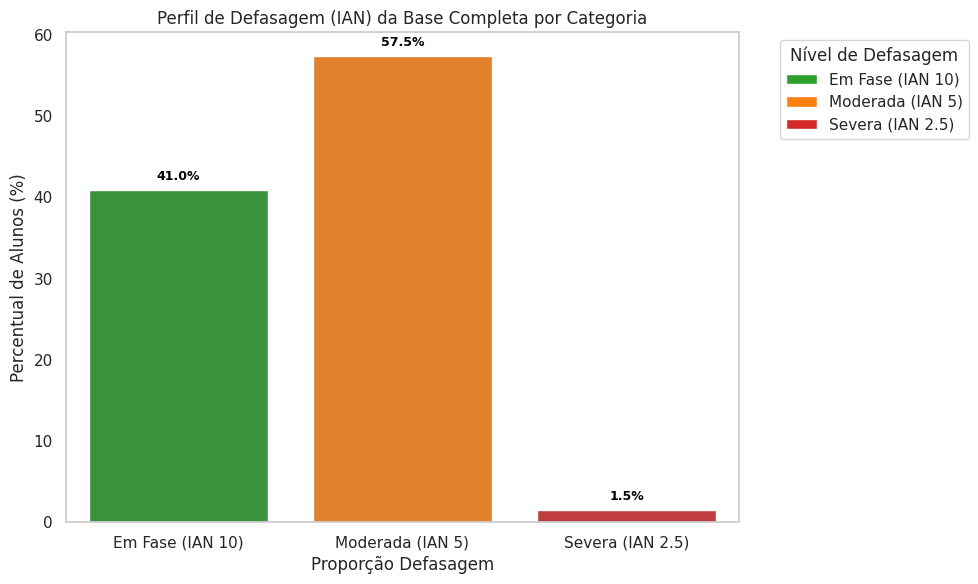

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Mapeando as categorias do IAN
df['CATEGORIA_DEFASAGEM'] = df['IAN'].map({
    10.0: 'Em Fase (IAN 10)',
    5.0: 'Moderada (IAN 5)',
    2.5: 'Severa (IAN 2.5)'
})

# Calculando a distribuição percentual para a base inteira
# Transformar para um formato longo adequado para seaborn.barplot
evolution_cat_df = (df['CATEGORIA_DEFASAGEM'].value_counts(normalize=True) * 100).reset_index()
evolution_cat_df.columns = ['CATEGORIA_DEFASAGEM', 'Proporção']

# Ordenando as colunas para o gráfico ficar lógico (Melhor para Pior ou Pior para Melhor)
cols = ['Em Fase (IAN 10)', 'Moderada (IAN 5)', 'Severa (IAN 2.5)']
evolution_cat_df['CATEGORIA_DEFASAGEM'] = pd.Categorical(evolution_cat_df['CATEGORIA_DEFASAGEM'], categories=cols, ordered=True)
evolution_cat_df = evolution_cat_df.sort_values('CATEGORIA_DEFASAGEM')

# Definindo as cores customizadas
cores = ['#2ca02c', '#ff7f0e', '#d62728']
cores_dict = dict(zip(cols, cores)) # Map categories to colors

# Gerando o gráfico como barras individuais para cada categoria ('fase')
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='CATEGORIA_DEFASAGEM', y='Proporção', hue='CATEGORIA_DEFASAGEM', data=evolution_cat_df, palette=cores_dict, legend=False)

plt.title('Perfil de Defasagem (IAN) da Base Completa por Categoria')
plt.ylabel('Percentual de Alunos (%)')
ax.set_xlabel('Proporção Defasagem') # Define o rótulo do eixo X diretamente no objeto ax
plt.xticks(rotation=0) # Definido rotação horizontal para os rótulos do eixo X
plt.legend(title='Nível de Defasagem', handles=[plt.Rectangle((0,0),1,1, fc=cores_dict[label]) for label in cols], labels=cols, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Remover as linhas de grade internas
ax.grid(False)

# Adicionando os percentuais nas barras
for i, bar in enumerate(ax.patches):
    percentage = bar.get_height()
    if percentage > 0:
        ax.annotate(f'{percentage:.1f}%',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', color='black', fontsize=9, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points') # Move label to top with padding


# Salvando a nova imagem
plt.savefig('perfil_ian_base_completa.png')
print("")

Analisando o IAN detalhado por ano

<Figure size 1000x600 with 0 Axes>

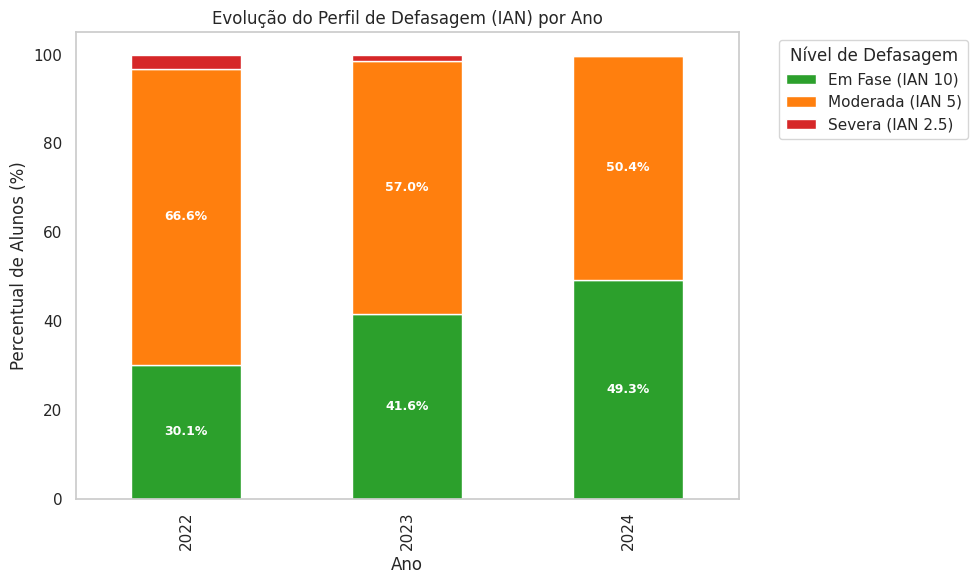

In [57]:
# Mapeando as categorias do IAN
df['CATEGORIA_DEFASAGEM'] = df['IAN'].map({
    10.0: 'Em Fase (IAN 10)',
    5.0: 'Moderada (IAN 5)',
    2.5: 'Severa (IAN 2.5)'
})

# Calculando a evolução (%)
evolution_cat = pd.crosstab(df['ANO'], df['CATEGORIA_DEFASAGEM'], normalize='index') * 100

# Ordenando as colunas para o gráfico ficar lógico (Melhor para Pior ou Pior para Melhor)
# Vamos colocar: Em Fase, Moderada, Severa
cols = ['Em Fase (IAN 10)', 'Moderada (IAN 5)', 'Severa (IAN 2.5)']
evolution_cat = evolution_cat[cols]

# Definindo as cores customizadas
# Verde para a melhor média (Em Fase), Amarelo para Moderada, Vermelho para Severa
cores = ['#2ca02c', '#ff7f0e', '#d62728']

# Gerando o gráfico
plt.figure(figsize=(10, 6))
ax = evolution_cat.plot(kind='bar', stacked=True, color=cores, figsize=(10,6))

plt.title('Evolução do Perfil de Defasagem (IAN) por Ano')
plt.ylabel('Percentual de Alunos (%)')
plt.xlabel('Ano')
plt.legend(title='Nível de Defasagem', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Remover as linhas de grade internas
ax.grid(False)

# Adicionando os percentuais nas barras
for i, c in enumerate(ax.containers):
    # Não adicionar rótulos para a categoria 'Severa (IAN 2.5)' (último container, índice 2)
    if i == len(ax.containers) - 1:
        continue
    # customize the labels over the bars
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=9, fontweight='bold')

# Salvando a nova imagem
plt.savefig('evolucao_ian_cores_atualizadas.png')
print("")


# 2. Desempenho Acadêmico (IDA)

###O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

--- IDA Médio por Ano ---
ANO
2022    6.09
2023    6.67
2024    6.35
Name: IDA, dtype: float64

--- IDA Médio por Fase Escolar ---
FASE_ESCOLAR
0    7.30
1    6.68
2    6.19
3    5.39
4    5.97
5    6.14
6    6.92
7    5.93
Name: IDA, dtype: float64

--- IDA Médio por Fase e Ano ---
ANO           2022  2023  2024
FASE_ESCOLAR                  
0             7.14  7.42  7.32
1             6.46  6.81  6.79
2             5.41  6.74  6.25
3             5.14  5.75  5.35
4             6.05  6.02  5.88
5             5.87  5.90  6.45
6             6.69  6.81  7.23
7             5.25  7.81  5.81




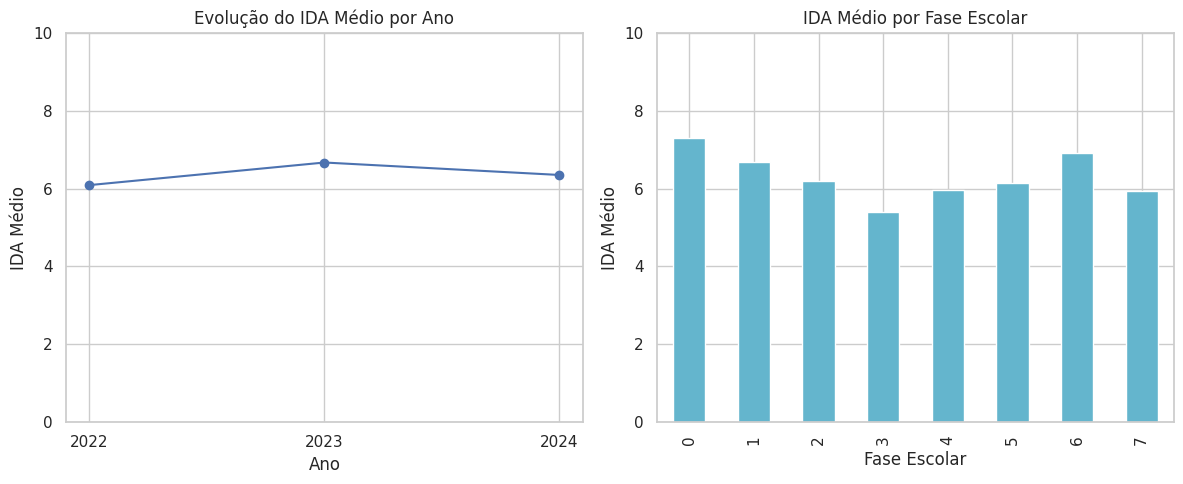

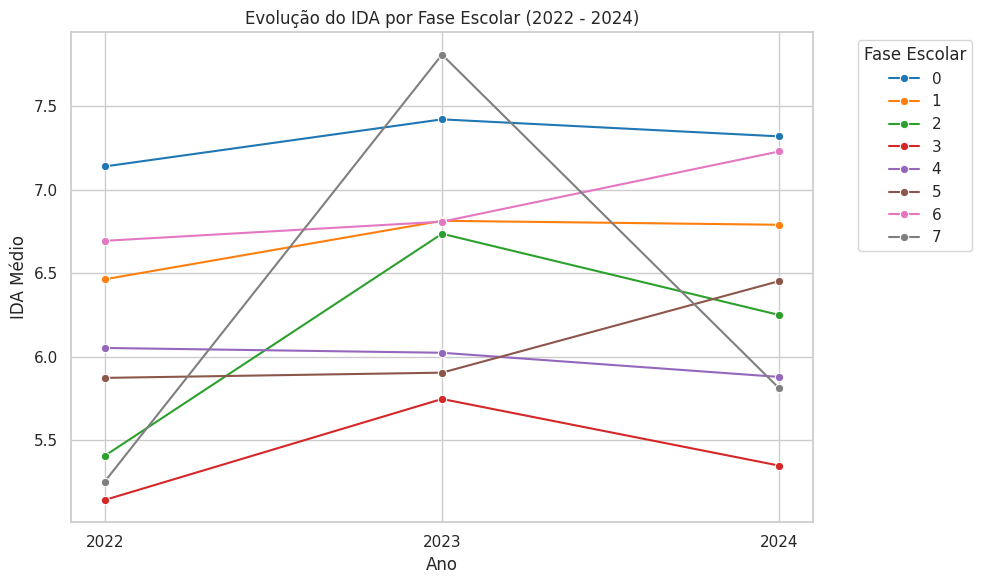

In [58]:
# 1. IDA médio por Ano
ida_por_ano = df.groupby('ANO')['IDA'].mean().round(2)
print("--- IDA Médio por Ano ---")
print(ida_por_ano)

# 2. IDA médio por Fase Escolar
ida_por_fase = df.groupby('FASE_ESCOLAR')['IDA'].mean().round(2)
print("\n--- IDA Médio por Fase Escolar ---")
print(ida_por_fase)

# 3. IDA médio por Ano e Fase Escolar (Pivot)
ida_pivot = df.pivot_table(index='FASE_ESCOLAR', columns='ANO', values='IDA', aggfunc='mean').round(2)
print("\n--- IDA Médio por Fase e Ano ---")
print(ida_pivot)
print("\n")

# Visualização: Evolução do IDA por Ano (Geral)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ida_por_ano.plot(kind='line', marker='o', color='b')
plt.title('Evolução do IDA Médio por Ano')
plt.ylabel('IDA Médio')
plt.xlabel('Ano')
plt.xticks(ida_por_ano.index)
plt.ylim(0, 10)
#plt.grid(False)

# Visualização: IDA Médio por Fase (Geral)
plt.subplot(1, 2, 2)
ida_por_fase.plot(kind='bar', color='c')
plt.title('IDA Médio por Fase Escolar')
plt.ylabel('IDA Médio')
plt.xlabel('Fase Escolar')
plt.ylim(0, 10)
#plt.grid(False)
plt.tight_layout()
plt.savefig('ida_geral.png')


# Visualização: Evolução do IDA por Fase ao longo dos anos
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='ANO', y='IDA', hue='FASE_ESCOLAR', marker='o', palette='tab10', errorbar=None)
plt.title('Evolução do IDA por Fase Escolar (2022 - 2024)')
plt.ylabel('IDA Médio')
plt.xlabel('Ano')
plt.xticks(df['ANO'].unique())
plt.legend(title='Fase Escolar', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid(False)
plt.tight_layout()
plt.savefig('ida_por_fase_ano.png')

Aqui detalhamos a evolução do IDA mais detalhamente por matéria: Portugês, Matemática de Inglês

--- Médias Gerais das Matérias por Ano ---
       MAT   POR   ING
ANO                   
2022  5.81  6.32  5.88
2023  6.41  6.82  6.21
2024  6.23  6.17  6.59

--- Médias da Fase 3 por Ano ---
       MAT   POR   ING
ANO                   
2022  4.91  5.63  5.13
2023  6.16  5.84  5.24
2024  5.37  5.02  5.70

--- Médias da Fase 7 por Ano ---
       MAT   POR   ING
ANO                   
2022  5.58  4.09  5.90
2023  8.04  7.11  8.31
2024  5.55  5.53  6.36


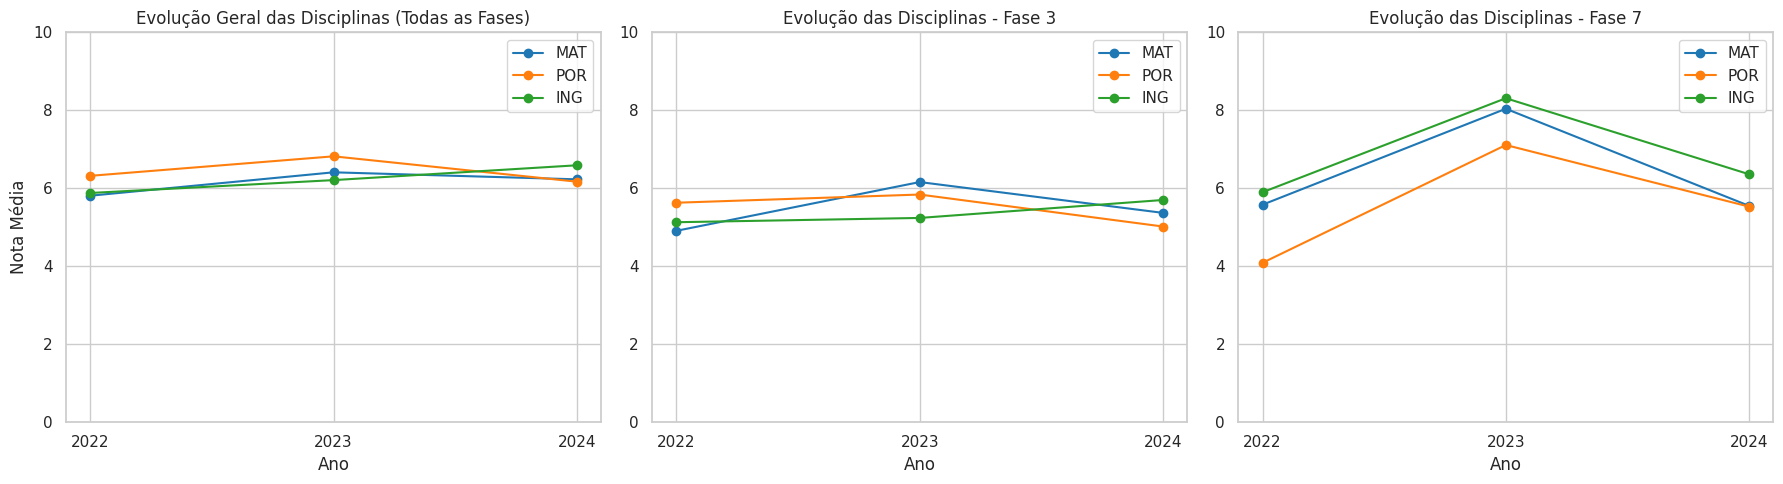

In [59]:
# 1. Evolução Geral das Matérias por Ano
materias_por_ano = df.groupby('ANO')[['MAT', 'POR', 'ING']].mean().round(2)
print("--- Médias Gerais das Matérias por Ano ---")
print(materias_por_ano)

# 2. Focar nas Fases Críticas (3 e 7)
fases_criticas = [3, 7]
df_critico = df[df['FASE_ESCOLAR'].isin(fases_criticas)]

materias_fase3 = df[df['FASE_ESCOLAR'] == 3].groupby('ANO')[['MAT', 'POR', 'ING']].mean().round(2)
materias_fase7 = df[df['FASE_ESCOLAR'] == 7].groupby('ANO')[['MAT', 'POR', 'ING']].mean().round(2)

print("\n--- Médias da Fase 3 por Ano ---")
print(materias_fase3)

print("\n--- Médias da Fase 7 por Ano ---")
print(materias_fase7)

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Geral
materias_por_ano.plot(kind='line', marker='o', ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Evolução Geral das Disciplinas (Todas as Fases)')
axes[0].set_ylabel('Nota Média')
axes[0].set_xlabel('Ano')
axes[0].set_xticks(materias_por_ano.index)
axes[0].set_ylim(0, 10)
#axes[0].grid(False)

# Plot Fase 3
materias_fase3.plot(kind='line', marker='o', ax=axes[1], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Evolução das Disciplinas - Fase 3')
axes[1].set_xlabel('Ano')
axes[1].set_xticks(materias_fase3.index)
axes[1].set_ylim(0, 10)
#axes[1].grid(False)

# Plot Fase 7
materias_fase7.plot(kind='line', marker='o', ax=axes[2], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_title('Evolução das Disciplinas - Fase 7')
axes[2].set_xlabel('Ano')
axes[2].set_xticks(materias_fase7.index)
axes[2].set_ylim(0, 10)
#axes[2].grid(False)

plt.tight_layout()
plt.savefig('materias_evolucao.png')

# 3. Engajamento nas atividades (IEG)

### O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

--- IEG (Engajamento) Médio ---
Geral:
 ANO
2022    7.89
2023    8.70
2024    8.09
Name: IEG, dtype: float64

Fase 7:
 ANO
2022    7.24
2023    9.17
2024    7.44
Name: IEG, dtype: float64

Fase 3:
 ANO
2022    7.07
2023    8.44
2024    7.39
Name: IEG, dtype: float64

--- IPS (Psicossocial) Médio ---
Geral:
 ANO
2022    6.90
2023    5.13
2024    6.83
Name: IPS, dtype: float64

Fase 7:
 ANO
2022    6.52
2023    6.01
2024    7.30
Name: IPS, dtype: float64

Fase 3:
 ANO
2022    6.72
2023    4.67
2024    7.17
Name: IPS, dtype: float64

Gráfico salvo como ieg_ips_analise.png


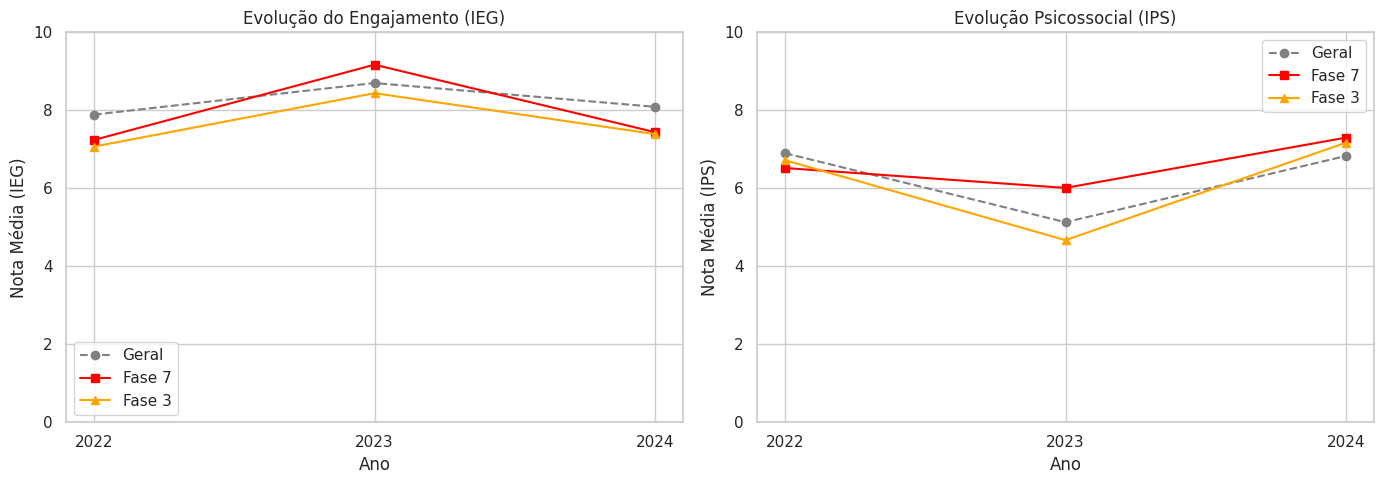

In [60]:
# Agrupamentos gerais
ieg_geral = df.groupby('ANO')['IEG'].mean().round(2)
ips_geral = df.groupby('ANO')['IPS'].mean().round(2)

# Agrupamentos Fase 7
df_fase7 = df[df['FASE_ESCOLAR'] == 7]
ieg_fase7 = df_fase7.groupby('ANO')['IEG'].mean().round(2)
ips_fase7 = df_fase7.groupby('ANO')['IPS'].mean().round(2)

# Agrupamentos Fase 3 (para comparação do outro gargalo)
df_fase3 = df[df['FASE_ESCOLAR'] == 3]
ieg_fase3 = df_fase3.groupby('ANO')['IEG'].mean().round(2)
ips_fase3 = df_fase3.groupby('ANO')['IPS'].mean().round(2)

print("--- IEG (Engajamento) Médio ---")
print("Geral:\n", ieg_geral)
print("\nFase 7:\n", ieg_fase7)
print("\nFase 3:\n", ieg_fase3)

print("\n--- IPS (Psicossocial) Médio ---")
print("Geral:\n", ips_geral)
print("\nFase 7:\n", ips_fase7)
print("\nFase 3:\n", ips_fase3)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot IEG
axes[0].plot(ieg_geral.index, ieg_geral.values, marker='o', label='Geral', linestyle='--', color='gray')
axes[0].plot(ieg_fase7.index, ieg_fase7.values, marker='s', label='Fase 7', color='red')
axes[0].plot(ieg_fase3.index, ieg_fase3.values, marker='^', label='Fase 3', color='orange')
axes[0].set_title('Evolução do Engajamento (IEG)')
axes[0].set_ylabel('Nota Média (IEG)')
axes[0].set_xlabel('Ano')
axes[0].set_xticks(ieg_geral.index)
axes[0].set_ylim(0, 10)
axes[0].legend()
#axes[0].grid(False)

# Plot IPS
axes[1].plot(ips_geral.index, ips_geral.values, marker='o', label='Geral', linestyle='--', color='gray')
axes[1].plot(ips_fase7.index, ips_fase7.values, marker='s', label='Fase 7', color='red')
axes[1].plot(ips_fase3.index, ips_fase3.values, marker='^', label='Fase 3', color='orange')
axes[1].set_title('Evolução Psicossocial (IPS)')
axes[1].set_ylabel('Nota Média (IPS)')
axes[1].set_xlabel('Ano')
axes[1].set_xticks(ips_geral.index)
axes[1].set_ylim(0, 10)
axes[1].legend()
#axes[1].grid(False)

plt.tight_layout()
plt.savefig('ieg_ips_analise.png')
print("\nGráfico salvo como ieg_ips_analise.png")

# 4. Autoavaliação (IAA)

###As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

ANALISANDO A CORRELAÇÃO ENTRE OS INDICADORES IAA, IDA E IEG

O objetivo aqui é analisar se o indice de auto avaliação dos alunos nos anos disponíveis na base de dados é coerente com os índices reais de desempenho e engajamento.

Começamos criando um heatmap para analisar a correlação entre as variáveis.



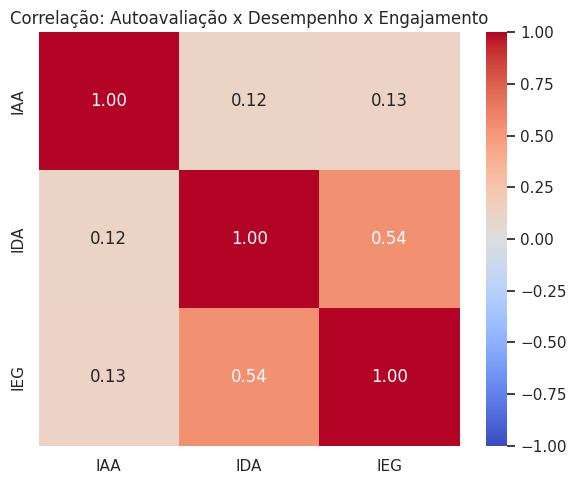

In [61]:
# Filtrando apenas as colunas de interesse e removendo nulos para análise de correlação justa
df_corr = df[['IAA', 'IDA', 'IEG']].dropna()

corr_matrix = df_corr.corr().round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Correlação: Autoavaliação x Desempenho x Engajamento')
plt.tight_layout()
plt.savefig('heatmap_iaa.png')


Ao analisar os valores apresentados no gráfico, é possível identificar que as percepções dos alunos não são coerentes com a realidade.

Desempenho Real (IDA) vs. Engajamento (IEG): Correlação de 0,54. Isso significa que existe uma relação moderada/forte e lógica aqui. Quem faz as tarefas e participatem engajamento (IEG) tende a tirar notas melhores (IDA).

Autoavaliação (IAA) vs. Desempenho (IDA): Correlação de apenas 0,12. Estatisticamente, isso é quase nulo. A forma como o aluno se avalia no questionário não reflete sua nota real.

Autoavaliação (IAA) vs. Engajamento (IEG): Correlação de apenas 0,13. Da mesma forma, o aluno que se dá uma nota altíssima no questionário de autoavaliação muitas vezes é o mesmo que não entrega as lições de casa.

Os cálculos abaixo tem por objetivo fazer uma conta percentual comparando alunos com índice de auto avaliação alto com desempenho e engajamento baixo.

Alunos com IAA Alto: representa o total de alunos que se autoavaliaram com 8 ou mais, sendo a base de 100% para a comparação.
IAA Alto & IDA Baixo: mostra o número e percentual de alunos com autoavaliação alta, mas com desempenho acadêmico baixo (IDA <= 5).
IAA Alto & IEG Baixo: indica o número e percentual de alunos com autoavaliação alta, mas com engajamento baixo (IEG <= 5).



--- Análise de Dissonância (Base: 2034 alunos com IAA >= 8) ---
Alunos com Autoavaliação Alta (>= 8) mas Desempenho Baixo (IDA <= 5): 444 (21.8%)
Alunos com Autoavaliação Alta (>= 8) mas Engajamento Baixo (IEG <= 5): 74 (3.6%)

Gráfico de barras da dissonância IAA (detalhado) salvo como dissonancia_iaa_bar_chart_detalhado.png


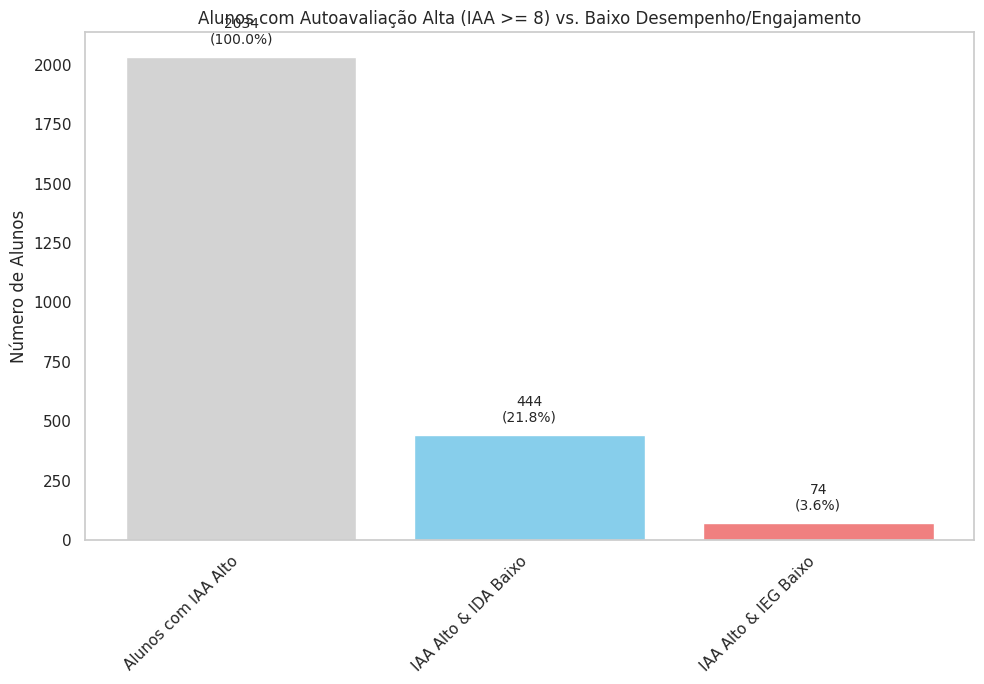

In [62]:
# Análise de Dissonância (Alunos que se avaliam bem, mas vão mal)
# Consideramos IAA Alto >= 8, IDA Baixo <= 5, IEG Baixo <= 5
total_high_iaa = len(df_corr[df_corr['IAA'] >= 8])

high_iaa_low_ida = len(df_corr[(df_corr['IAA'] >= 8) & (df_corr['IDA'] <= 5)])
pct_low_ida = (high_iaa_low_ida / total_high_iaa) * 100 if total_high_iaa > 0 else 0

high_iaa_low_ieg = len(df_corr[(df_corr['IAA'] >= 8) & (df_corr['IEG'] <= 5)])
pct_low_ieg = (high_iaa_low_ieg / total_high_iaa) * 100 if total_high_iaa > 0 else 0

print(f"\n--- Análise de Dissonância (Base: {total_high_iaa} alunos com IAA >= 8) ---")
print(f"Alunos com Autoavaliação Alta (>= 8) mas Desempenho Baixo (IDA <= 5): {high_iaa_low_ida} ({pct_low_ida:.1f}%)")
print(f"Alunos com Autoavaliação Alta (>= 8) mas Engajamento Baixo (IEG <= 5): {high_iaa_low_ieg} ({pct_low_ieg:.1f}%)\n")

# Criando um gráfico de barras para visualizar esses valores, incluindo o total
labels = [
    'Alunos com IAA Alto',
    'IAA Alto & IDA Baixo',
    'IAA Alto & IEG Baixo'
]
values = [total_high_iaa, high_iaa_low_ida, high_iaa_low_ieg]
percentages_for_labels = ['100.0%', f'{pct_low_ida:.1f}%', f'{pct_low_ieg:.1f}%']

plt.figure(figsize=(10, 7))
bars = plt.bar(labels, values, color=['lightgray', 'skyblue', 'lightcoral'])
plt.ylabel('Número de Alunos')
plt.title('Alunos com Autoavaliação Alta (IAA >= 8) vs. Baixo Desempenho/Engajamento')

# Adicionando rótulos de valor e porcentagem nas barras
for bar, percentage_label in zip(bars, percentages_for_labels):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(values) * 0.02),
             f'{int(yval)}\n({percentage_label})', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.savefig('dissonancia_iaa_bar_chart_detalhado.png')
print("Gráfico de barras da dissonância IAA (detalhado) salvo como dissonancia_iaa_bar_chart_detalhado.png")

Para ter uma visão por ano, apresentamos um gráfico linear comparando ao longo do tempo as 3 variáveis

--- Médias por Ano ---
       IEG   IDA   IAA
ANO                   
2022  7.89  6.09  8.27
2023  8.70  6.67  6.91
2024  8.09  6.35  8.54


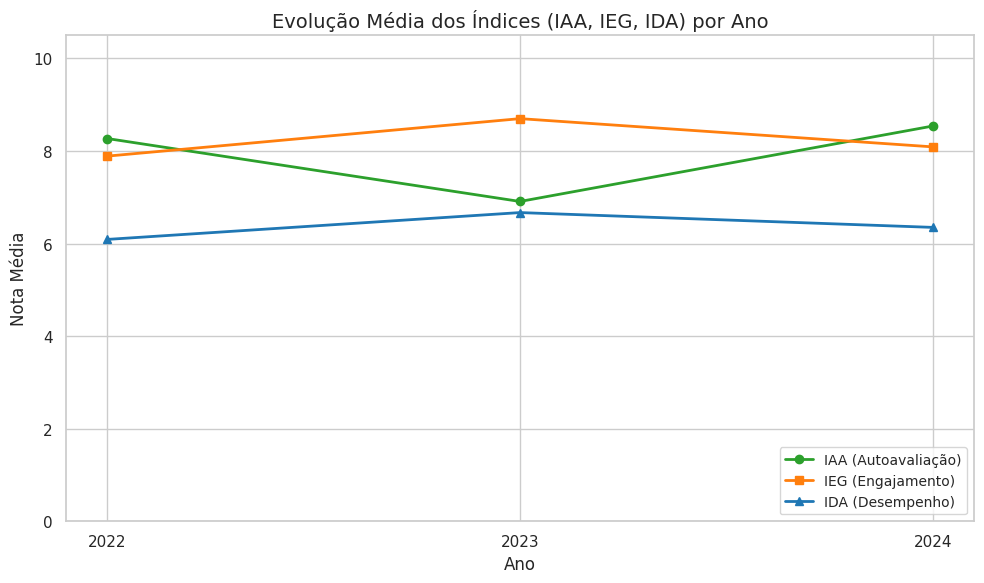

In [63]:
# Calculando a média dos índices por ano
medias_ano = df.groupby('ANO')[['IEG', 'IDA', 'IAA']].mean().round(2)

print("--- Médias por Ano ---")
print(medias_ano)

# Criando o gráfico de linha simples
plt.figure(figsize=(10, 6))

# Plotando cada índice
plt.plot(medias_ano.index, medias_ano['IAA'], marker='o', label='IAA (Autoavaliação)', color='#2ca02c', linewidth=2)
plt.plot(medias_ano.index, medias_ano['IEG'], marker='s', label='IEG (Engajamento)', color='#ff7f0e', linewidth=2)
plt.plot(medias_ano.index, medias_ano['IDA'], marker='^', label='IDA (Desempenho)', color='#1f77b4', linewidth=2)

# Configurações do gráfico
plt.title('Evolução Média dos Índices (IAA, IEG, IDA) por Ano', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)
plt.xticks(medias_ano.index)
plt.ylim(0, 10.5)
plt.legend(loc='lower right', fontsize=10)
#plt.grid(False)

plt.tight_layout()
plt.savefig('comparativo_indices_simples.png')

Para identificar com maior precisão onde estão as maiores dificuldades dos alunos, vamos detalhar os indicadores utilizados para calcular o IDA

--- Médias das Disciplinas por Ano ---
       MAT   POR   ING
ANO                   
2022  5.81  6.32  5.88
2023  6.41  6.82  6.21
2024  6.23  6.17  6.59


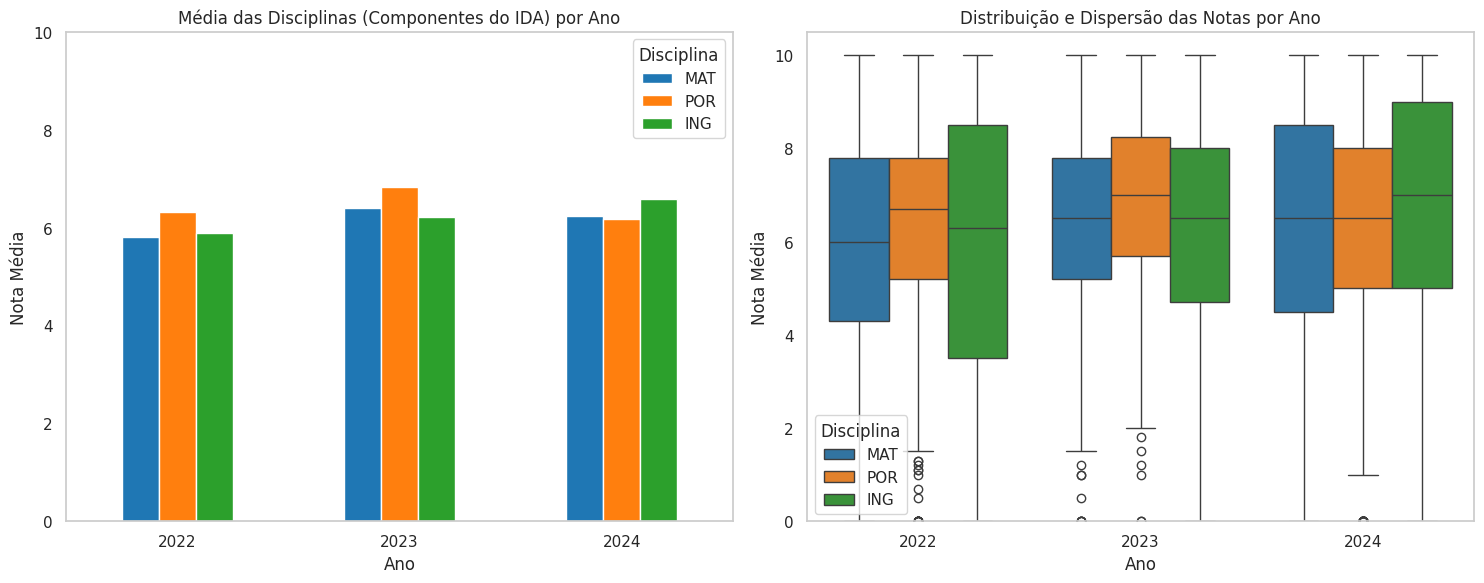

In [64]:
# O IDA é composto pelas notas de Matemática (MAT), Português (POR) e Inglês (ING)
# Calculando as médias por ano
medias_materias = df.groupby('ANO')[['MAT', 'POR', 'ING']].mean().round(2)
print("--- Médias das Disciplinas por Ano ---")
print(medias_materias)

# Criando a visualização com dois painéis: Médias e Distribuição (Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Painel 1: Gráfico de Barras Agrupadas (Médias)
medias_materias.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Média das Disciplinas (Componentes do IDA) por Ano')
axes[0].set_ylabel('Nota Média')
axes[0].set_xlabel('Ano')
axes[0].set_ylim(0, 10)
axes[0].grid(False)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Disciplina')

# Painel 2: Boxplot (Distribuição das Notas)
# Preparando os dados (melt) para o boxplot
df_melted = df.melt(id_vars=['ANO'], value_vars=['MAT', 'POR', 'ING'], var_name='Disciplina', value_name='Nota')
df_melted = df_melted.dropna()

sns.boxplot(data=df_melted, x='ANO', y='Nota', hue='Disciplina', ax=axes[1], palette=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Distribuição e Dispersão das Notas por Ano')
axes[1].set_ylabel('Nota Média')
axes[1].set_xlabel('Ano')
axes[1].set_ylim(0, 10.5)
axes[1].grid(False)

plt.tight_layout()
plt.savefig('ida_componentes_detalhado.png')

# 5. Aspectos psicossociais (IPS)

###Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

Abaixo analisamos o percurso dos mesmos alunos na base de dados (cruzando os dados de um ano, "Ano T", com os resultados do ano seguinte, "Ano T+1") para verificar se a avaliação psicossocial feita pelas psicólogas (IPS) funciona como um preditor de quedas acadêmicas ou de engajamento

--- Análise Descritiva: IPS Antecedendo Quedas ---

Média do IPS (Ano T) vs Comportamento do IDA (Ano T+1):
           mean  median  count
Queda_IDA                     
False      6.03     6.9    746
True       5.80     6.3    502

Média do IPS (Ano T) vs Comportamento do IEG (Ano T+1):
           mean  median  count
Queda_IEG                     
False      6.08    6.90    814
True       5.68    6.27    434

--- Correlação: IPS(Ano T) com Variação de Desempenho(Ano T+1) ---
             IPS  Delta_IDA  Delta_IEG
IPS        1.000      0.120      0.197
Delta_IDA  0.120      1.000      0.395
Delta_IEG  0.197      0.395      1.000


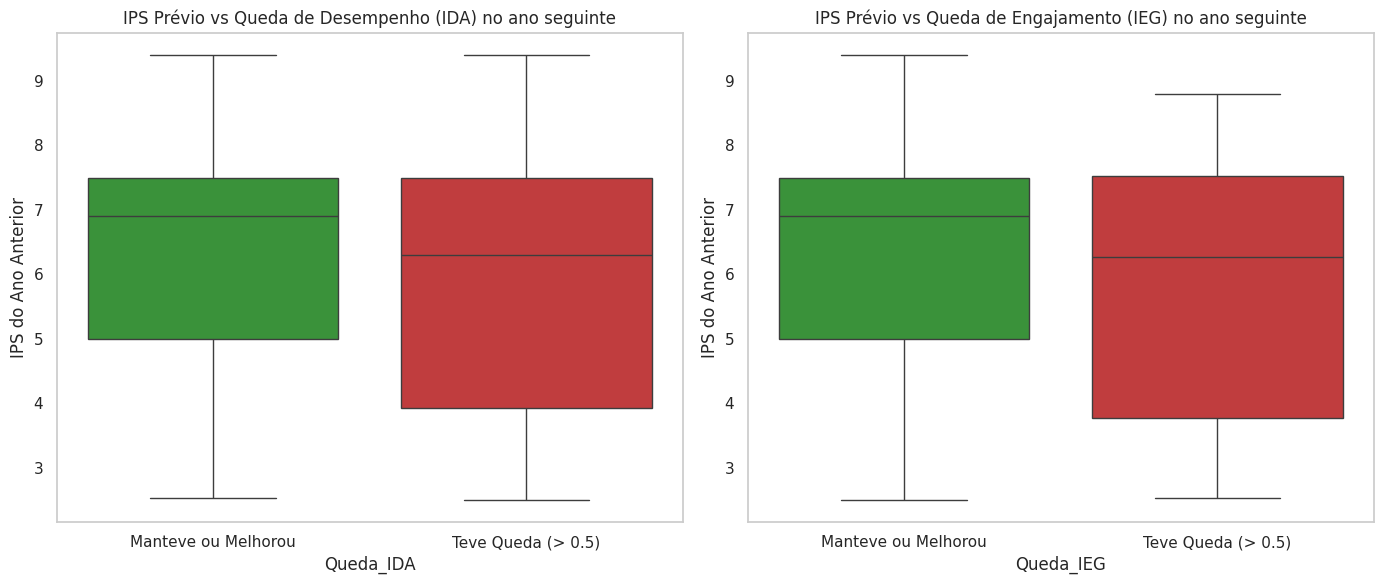

In [65]:
# Preparar dados longitudinais (rastreando o mesmo aluno de um ano para o outro)
df = df.sort_values(by=['RA', 'ANO'])

# Criar dataframe com os dados do 'próximo ano' para cruzar
df_next = df[['RA', 'ANO', 'IDA', 'IEG']].copy()
df_next['ANO'] = df_next['ANO'] - 1  # Subtrai 1 para alinhar Ano T com Ano T+1
df_next = df_next.rename(columns={'IDA': 'IDA_next', 'IEG': 'IEG_next'})

# Mesclar para ter Ano T e Ano T+1 na mesma linha
df_merged = pd.merge(df, df_next, on=['RA', 'ANO'], how='inner')

# Calcular variações (Delta)
df_merged['Delta_IDA'] = df_merged['IDA_next'] - df_merged['IDA']
df_merged['Delta_IEG'] = df_merged['IEG_next'] - df_merged['IEG']

# Definir o que é uma "Queda" (vamos considerar uma queda sensível, ex: < -0.5 pontos)
df_merged['Queda_IDA'] = df_merged['Delta_IDA'] < -0.5
df_merged['Queda_IEG'] = df_merged['Delta_IEG'] < -0.5

print("--- Análise Descritiva: IPS Antecedendo Quedas ---")
print("\nMédia do IPS (Ano T) vs Comportamento do IDA (Ano T+1):")
print(df_merged.groupby('Queda_IDA')['IPS'].agg(['mean', 'median', 'count']).round(2))

print("\nMédia do IPS (Ano T) vs Comportamento do IEG (Ano T+1):")
print(df_merged.groupby('Queda_IEG')['IPS'].agg(['mean', 'median', 'count']).round(2))

# Correlação direta
corr = df_merged[['IPS', 'Delta_IDA', 'Delta_IEG']].corr().round(3)
print("\n--- Correlação: IPS(Ano T) com Variação de Desempenho(Ano T+1) ---")
print(corr)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_merged, x='Queda_IDA', y='IPS', hue='Queda_IDA', ax=axes[0], palette=['#2ca02c', '#d62728'], legend=False)
axes[0].set_title('IPS Prévio vs Queda de Desempenho (IDA) no ano seguinte')
axes[0].set_xticks([0, 1]) # Fix: Explicitly set ticks before setting labels
axes[0].set_xticklabels(['Manteve ou Melhorou', 'Teve Queda (> 0.5)'])
axes[0].set_ylabel('IPS do Ano Anterior')
axes[0].grid(False)

sns.boxplot(data=df_merged, x='Queda_IEG', y='IPS', hue='Queda_IEG', ax=axes[1], palette=['#2ca02c', '#d62728'], legend=False)
axes[1].set_title('IPS Prévio vs Queda de Engajamento (IEG) no ano seguinte')
axes[1].set_xticks([0, 1]) # Fix: Explicitly set ticks before setting labels
axes[1].set_xticklabels(['Manteve ou Melhorou', 'Teve Queda (> 0.5)'])
axes[1].set_ylabel('IPS do Ano Anterior')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('ips_preditivo.png')

# 6. Aspectos psicopedagógicos (IPP)

### As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

Para analisar se as avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN, criamos um gráfico de correlação linear de Spearman.

--- Resumo do IPP por Categoria de Defasagem (IAN) ---
               count  mean  median   std
CATEGORIA_IAN                           
Em Fase (10)     907  7.68    7.71  0.89
Moderada (5)    1062  7.46    7.50  0.96
Severa (2.5)      16  6.95    7.27  1.14

--- Correlação (Pearson) ---
             IPP    IAN  DEFASAGEM
IPP        1.000  0.123      0.181
IAN        0.123  1.000      0.855
DEFASAGEM  0.181  0.855      1.000

--- Correlação (Spearman - melhor para dados ordinais) ---
             IPP    IAN  DEFASAGEM
IPP        1.000  0.131      0.174
IAN        0.131  1.000      0.934
DEFASAGEM  0.174  0.934      1.000
2


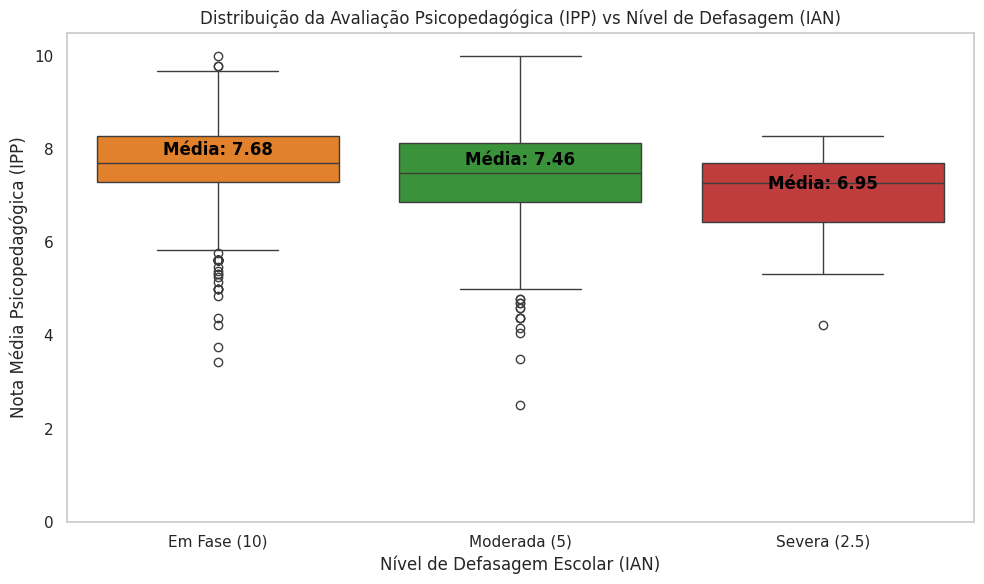

In [66]:
# Filtrar dados válidos (remover nulos de IPP)
df_valid = df.dropna(subset=['IPP', 'IAN', 'DEFASAGEM']).copy()

# Criar categorias descritivas para o IAN para o gráfico
df_valid['CATEGORIA_IAN'] = df_valid['IAN'].map({
    10.0: 'Em Fase (10)',
    5.0: 'Moderada (5)',
    2.5: 'Severa (2.5)'
})

# Ordem para o gráfico
ordem_ian = ['Em Fase (10)', 'Moderada (5)', 'Severa (2.5)']

# 1. Análise Descritiva: Média do IPP por Categoria do IAN
resumo_ipp_ian = df_valid.groupby('CATEGORIA_IAN')['IPP'].agg(['count', 'mean', 'median', 'std']).reindex(ordem_ian)
print("--- Resumo do IPP por Categoria de Defasagem (IAN) ---")
print(resumo_ipp_ian.round(2))

# 2. Correlação (Pearson e Spearman)
corr_pearson = df_valid[['IPP', 'IAN', 'DEFASAGEM']].corr(method='pearson').round(3)
corr_spearman = df_valid[['IPP', 'IAN', 'DEFASAGEM']].corr(method='spearman').round(3)

print("\n--- Correlação (Pearson) ---")
print(corr_pearson)
print("\n--- Correlação (Spearman - melhor para dados ordinais) ---")
print(corr_spearman)

# 3. Visualização (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_valid, x='CATEGORIA_IAN', y='IPP', order=ordem_ian, palette=['#2ca02c', '#ff7f0e', '#d62728'], hue='CATEGORIA_IAN', legend=False)
plt.title('Distribuição da Avaliação Psicopedagógica (IPP) vs Nível de Defasagem (IAN)')
plt.xlabel('Nível de Defasagem Escolar (IAN)')
plt.ylabel('Nota Média Psicopedagógica (IPP)')
plt.ylim(0, 10.5)
plt.grid(False)

# Adicionando as médias no gráfico para facilitar a leitura
medias = df_valid.groupby('CATEGORIA_IAN')['IPP'].mean().reindex(ordem_ian)
for i, media in enumerate(medias):
    plt.text(i, media + 0.2, f'Média: {media:.2f}', horizontalalignment='center', color='black', weight='bold')

plt.tight_layout()
plt.savefig('ipp_vs_ian.png')
print(2)

# 7. Ponto de virada (IPV)


###Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

Os dados foram analisados utilizando os anos de 2023 e 2024, pois o indice IPP está sem valores no ano de 2022

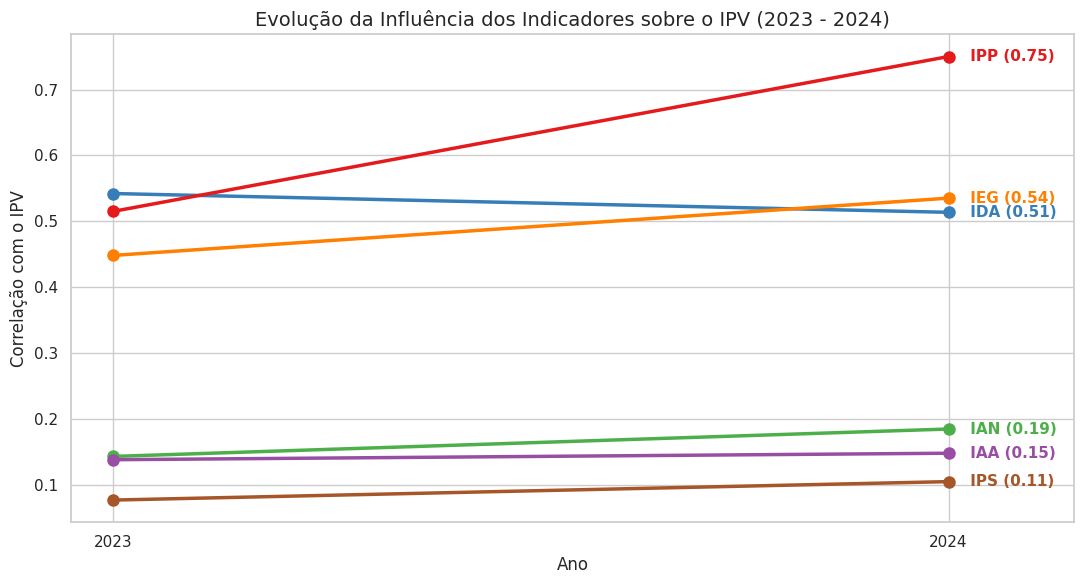

In [67]:
colunas_analise = ['IPV', 'IDA', 'IAN', 'IPS', 'IPP', 'IAA', 'IEG', 'ANO']
df_analise = df[colunas_analise].dropna()

# Calculations
corr_por_ano = {}
for ano in sorted(df_analise['ANO'].unique()):
    df_ano = df_analise[df_analise['ANO'] == ano].drop(columns=['ANO'])
    corr_por_ano[ano] = df_ano.corr(method='pearson')['IPV']
df_corr_ano = pd.DataFrame(corr_por_ano).drop(index='IPV')

# Paleta de cores de alto contraste
color_map = {
    'IPP': '#e41a1c',
    'IEG': '#ff7f00',
    'IDA': '#377eb8',
    'IAN': '#4daf4a',
    'IAA': '#984ea3',
    'IPS': '#a65628'
}

plt.figure(figsize=(11, 6)) # Aumentei um pouco a largura para caber os textos
for indicador in df_corr_ano.index:
    plt.plot(df_corr_ano.columns, df_corr_ano.loc[indicador], marker='o',
             color=color_map[indicador], linewidth=2.5, markersize=8)

    # Pegando o último ano e o valor final da correlação para posicionar o texto
    ultimo_ano = df_corr_ano.columns[-1]
    valor_final = df_corr_ano.loc[indicador, ultimo_ano]

    # Adicionando o rótulo no final da linha
    plt.text(ultimo_ano + 0.02, valor_final, f' {indicador} ({valor_final:.2f})',
             color=color_map[indicador], fontsize=11, weight='bold', va='center')

plt.title('Evolução da Influência dos Indicadores sobre o IPV (2023 - 2024)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Correlação com o IPV', fontsize=12)
plt.xticks(df_corr_ano.columns)

# Ajustando o limite do eixo X para dar espaço para os rótulos à direita
plt.xlim(df_corr_ano.columns[0] - 0.05, df_corr_ano.columns[-1] + 0.15)

plt.grid(True)
plt.tight_layout()
plt.savefig('evolucao_influencia_ipv_labels.png')

In [68]:
import matplotlib.pyplot as plt

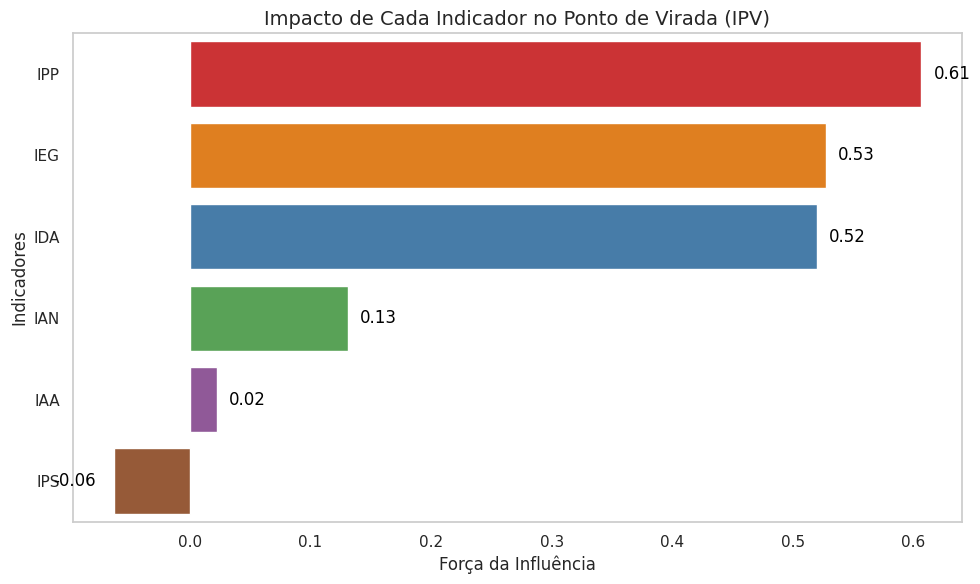

In [69]:


corr_pearson = df_analise.drop(columns=['ANO']).corr(method='pearson')[['IPV']].sort_values(by='IPV', ascending=False)

plt.figure(figsize=(10, 6))
corr_plot = corr_pearson.drop(index='IPV')
cores_bar = [color_map[idx] for idx in corr_plot.index]

sns.barplot(x=corr_plot['IPV'], y=corr_plot.index, palette=cores_bar, hue=corr_plot.index, legend=False)
plt.title('Impacto de Cada Indicador no Ponto de Virada (IPV)', fontsize=14)
plt.xlabel('Força da Influência', fontsize=12)
plt.ylabel('Indicadores', fontsize=12)
plt.grid(False)

# Adicionando os valores nas barras para facilitar ainda mais a leitura
for i, v in enumerate(corr_plot['IPV']):
    plt.text(v + 0.01 if v > 0 else v - 0.05, i, f"{v:.2f}", color='black', va='center')

plt.tight_layout()


# 8. Multidimensionalidade dos indicadores

### Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?


In [70]:
from sklearn.linear_model import LinearRegression

--- Correlação com o INDE ---
          INDE
INDE  1.000000
IDA   0.766739
IEG   0.708807
IPP   0.540331
IPS   0.247650

--- Coeficientes da Regressão Linear Múltipla ---
  Indicador  Peso_Empirico (Coef)
1       IEG              0.254872
0       IDA              0.237173
3       IPP              0.226701
2       IPS              0.117738

--- Médias dos Indicadores por Classificação (Pedra) ---
           IDA   IEG   IPS   IPP  INDE
PEDRAANO                              
Agata     5.26  7.59  5.99  7.19  6.59
Ametista  6.81  8.68  6.31  7.60  7.52
Quartzo   3.46  5.61  5.79  6.55  5.37
Topazio   8.18  9.38  6.84  8.13  8.44




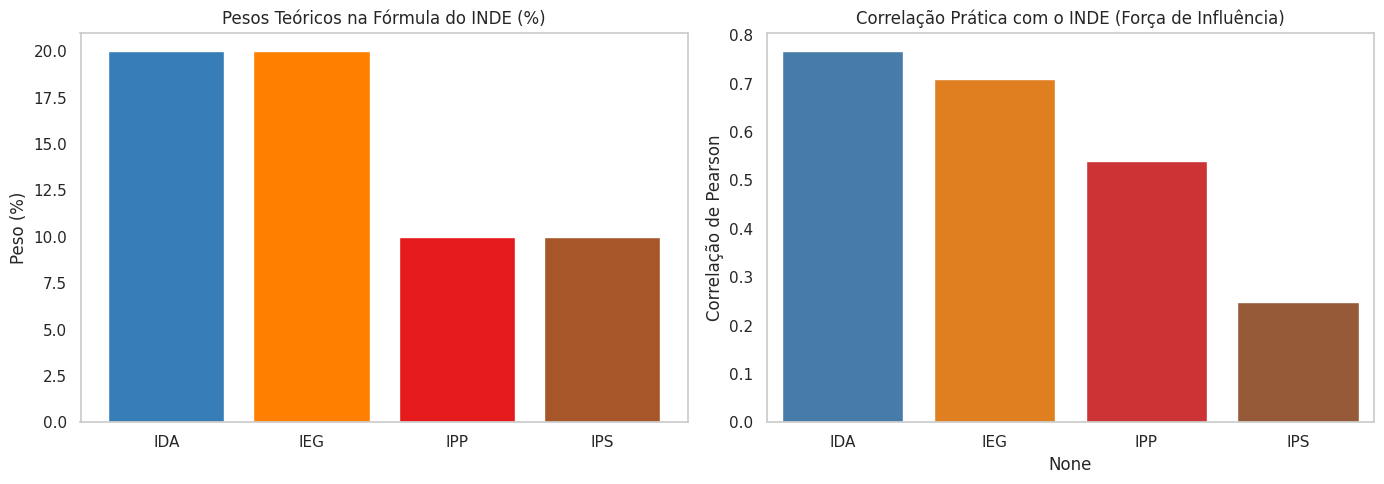

In [71]:
from sklearn.linear_model import LinearRegression
# Focar nos indicadores solicitados e no INDE
colunas_foco = ['INDE', 'IDA', 'IEG', 'IPS', 'IPP']
df_foco = df[colunas_foco].dropna()

# 1. Correlação de Pearson
corr = df_foco.corr()[['INDE']].sort_values(by='INDE', ascending=False)
print("--- Correlação com o INDE ---")
print(corr)

# 2. Regressão Linear para ver o peso empírico na variação da base
X = df_foco[['IDA', 'IEG', 'IPS', 'IPP']]
y = df_foco['INDE']

model = LinearRegression()
model.fit(X, y)
coeficientes = pd.DataFrame({'Indicador': X.columns, 'Peso_Empirico (Coef)': model.coef_})
coeficientes = coeficientes.sort_values(by='Peso_Empirico (Coef)', ascending=False)
print("\n--- Coeficientes da Regressão Linear Múltipla ---")
print(coeficientes)

# Vamos analisar os dados agrupando os alunos de "alta performance" (Topázio)
df['PEDRAANO'] = df['PEDRAANO'].fillna('Sem Pedra')
media_pedras = df.groupby('PEDRAANO')[['IDA', 'IEG', 'IPS', 'IPP', 'INDE']].mean().round(2)
print("\n--- Médias dos Indicadores por Classificação (Pedra) ---")
print(media_pedras)
print()
print()

# Gráfico da Composição Teórica vs Influência Prática
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pesos Teóricos (Fases 0 a 7 baseados na imagem)
pesos_teoricos = {'IDA': 20, 'IEG': 20, 'IPP': 10, 'IPS': 10}
cores = ['#377eb8', '#ff7f00', '#e41a1c', '#a65628']

axes[0].bar(pesos_teoricos.keys(), pesos_teoricos.values(), color=cores)
axes[0].set_title('Pesos Teóricos na Fórmula do INDE (%)')
axes[0].set_ylabel('Peso (%)')
axes[0].grid(False)

# Correlação Empírica (Prática)
sns.barplot(x=corr.index[1:], y=corr['INDE'].values[1:], ax=axes[1], palette=cores, hue=corr.index[1:], legend=False)
axes[1].set_title('Correlação Prática com o INDE (Força de Influência)')
axes[1].set_ylabel('Correlação de Pearson')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('inde_influencia.png')

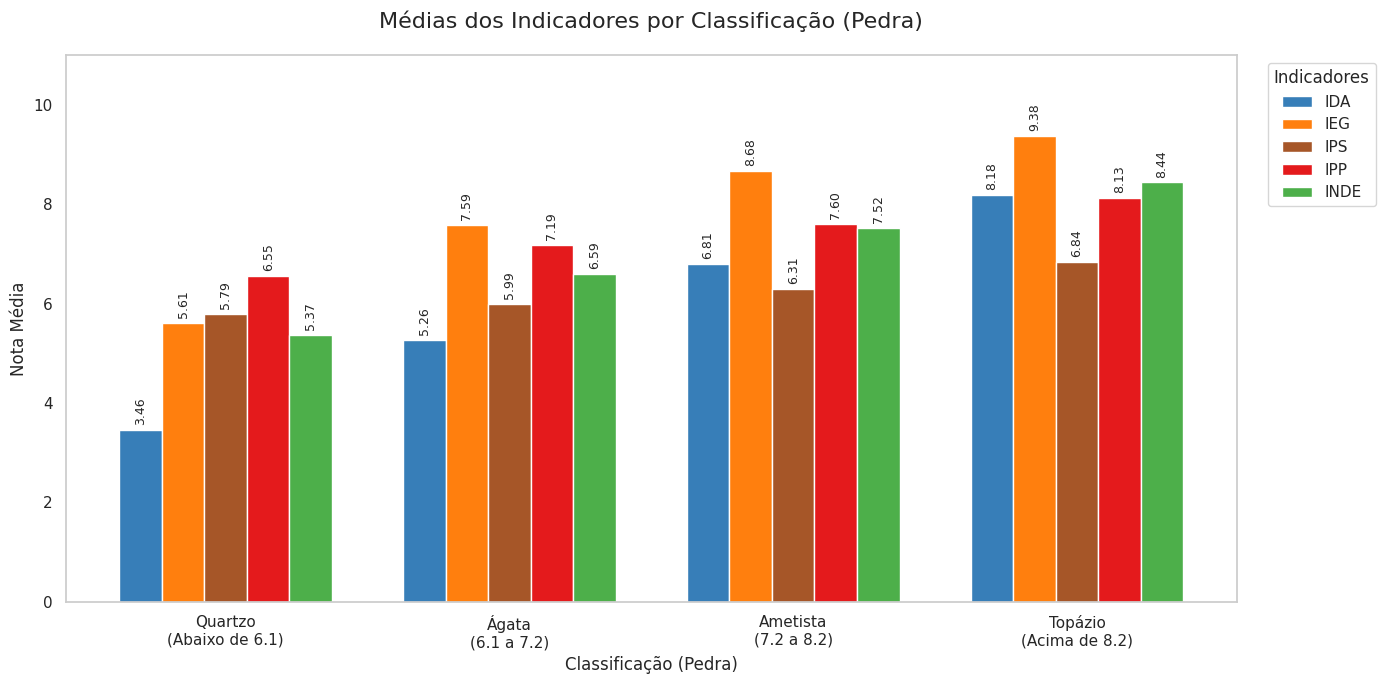

In [72]:
# Limpar e preparar os dados
df_pedras = df[['PEDRAANO', 'IDA', 'IEG', 'IPS', 'IPP', 'INDE']].dropna(subset=['PEDRAANO'])

# O dataset contém valores sem acento, vamos definir a ordem correta
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_pedras = df_pedras[df_pedras['PEDRAANO'].isin(ordem_pedras)]

# Calcular as médias por Pedra
medias_pedras = df_pedras.groupby('PEDRAANO')[['IDA', 'IEG', 'IPS', 'IPP', 'INDE']].mean().reindex(ordem_pedras)

# Configurações do gráfico
plt.figure(figsize=(14, 7))

# Definir largura das barras e posições
bar_width = 0.15
x = np.arange(len(ordem_pedras))

# Paleta de cores para os indicadores
cores = {'IDA': '#377eb8', 'IEG': '#ff7f0e', 'IPS': '#a65628', 'IPP': '#e41a1c', 'INDE': '#4daf4a'}

# Plotar as barras
for i, indicador in enumerate(['IDA', 'IEG', 'IPS', 'IPP', 'INDE']):
    valores = medias_pedras[indicador].values
    posicoes = x + (i - 2) * bar_width
    barras = plt.bar(posicoes, valores, bar_width, label=indicador, color=cores[indicador])

    # Adicionar rótulos de dados em cima das barras
    for barra in barras:
        altura = barra.get_height()
        if not np.isnan(altura):
            plt.text(barra.get_x() + barra.get_width()/2., altura + 0.1,
                     f'{altura:.2f}', ha='center', va='bottom', fontsize=9, rotation=90)

# Formatação do gráfico
plt.title('Médias dos Indicadores por Classificação (Pedra)', fontsize=16, pad=20)
plt.xlabel('Classificação (Pedra)', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)
plt.xticks(x, ['Quartzo\n(Abaixo de 6.1)', 'Ágata\n(6.1 a 7.2)', 'Ametista\n(7.2 a 8.2)', 'Topázio\n(Acima de 8.2)'], fontsize=11)
plt.ylim(0, 11)
plt.legend(title='Indicadores', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(False)

plt.tight_layout()
plt.savefig('analise_por_pedra.png')
print("")

# 9. Previsão de risco com Machine Learning

### Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

--- Total de Casos Analisados ---
Em_Risco_Futuro
False    686
True     555
Name: count, dtype: int64
--- Médias dos Indicadores no Ano T ---
                  IDA   IEG   IPS   IAA   IPP
Em_Risco_Futuro                              
False            6.47  8.55  5.96  7.77  7.68
True             6.94  8.71  5.94  7.56  7.54
--- Probabilidade de Falha/Queda por Nível de Engajamento Prévio (%) ---
IEG_Faixa
Baixo (0-6)      28.3
Médio (6-8.5)    44.5
Alto (>8.5)      45.8
Name: Em_Risco_Futuro, dtype: float64


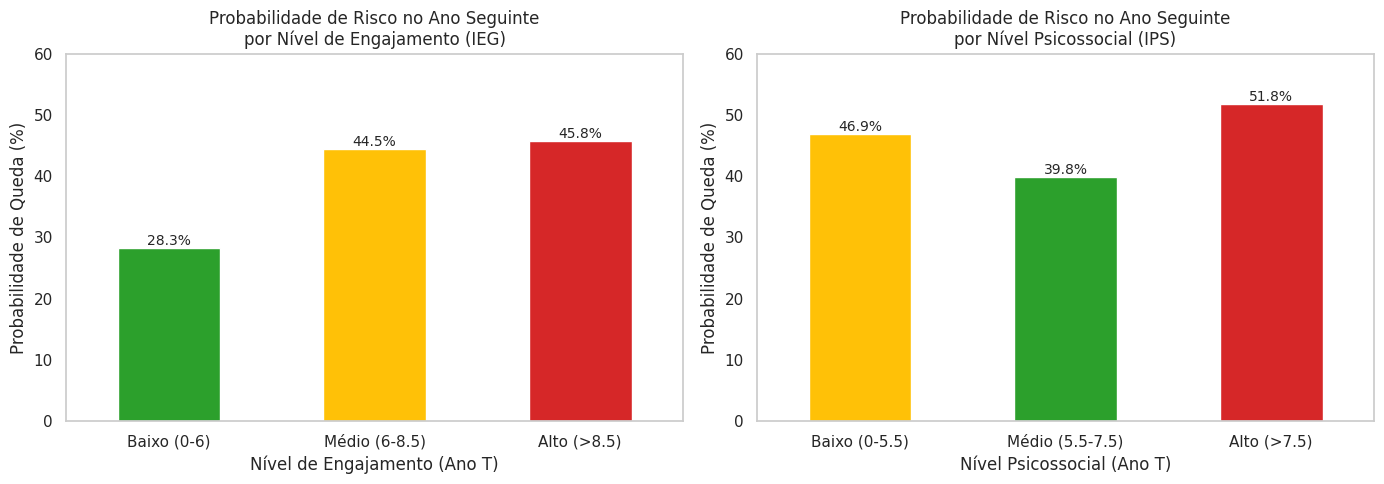

In [73]:
# Ordenar para análise longitudinal
df = df.sort_values(by=['RA', 'ANO'])

# Remover alunos onde IDA é igual a zero
df = df[df['IDA'] != 0].copy()

# Criar dataframe do Ano T+1
df_next = df[['RA', 'ANO', 'IDA', 'DEFASAGEM', 'IAN']].copy()
df_next['ANO'] = df_next['ANO'] - 1  # Alinha Ano T com os resultados do Ano T+1
df_next = df_next.rename(columns={'IDA': 'IDA_next', 'DEFASAGEM': 'DEFASAGEM_next', 'IAN': 'IAN_next'})

# Mesclar
df_merged = pd.merge(df, df_next, on=['RA', 'ANO'], how='inner')

# Definir o que é um "Aluno em Risco" no Ano T+1
# 1. Queda acadêmica severa (perdeu mais de 1 ponto no IDA)
df_merged['Queda_Severa_IDA'] = (df_merged['IDA_next'] - df_merged['IDA']) <= -1.0
# 2. Piora na defasagem (a defasagem ficou mais negativa)
df_merged['Piora_Defasagem'] = (df_merged['DEFASAGEM_next'] - df_merged['DEFASAGEM']) < 0

# Risco Geral = Qualquer uma das duas situações
df_merged['Em_Risco_Futuro'] = df_merged['Queda_Severa_IDA'] | df_merged['Piora_Defasagem']

print("--- Total de Casos Analisados ---")
print(df_merged['Em_Risco_Futuro'].value_counts())

# Perfil dos indicadores no Ano T para alunos que VÃO entrar em risco no T+1
analise_cols = ['IDA', 'IEG', 'IPS', 'IAA', 'IPP']
resumo_medias = df_merged.groupby('Em_Risco_Futuro')[analise_cols].mean().round(2)
print(
"--- Médias dos Indicadores no Ano T ---")
print(resumo_medias)

# Analisando a probabilidade de risco baseado em faixas de Engajamento (IEG)
df_merged['IEG_Faixa'] = pd.cut(df_merged['IEG'], bins=[-1, 5.9, 8.5, 11], labels=['Baixo (0-6)', 'Médio (6-8.5)', 'Alto (>8.5)'])
prob_risco_ieg = (df_merged.groupby('IEG_Faixa', observed=False)['Em_Risco_Futuro'].mean() * 100).round(1)
print(
"--- Probabilidade de Falha/Queda por Nível de Engajamento Prévio (%) ---")
print(prob_risco_ieg)

# Analisando a probabilidade de risco baseado no IPS
df_merged['IPS_Faixa'] = pd.cut(df_merged['IPS'], bins=[-1, 5.5, 7.5, 11], labels=['Baixo (0-5.5)', 'Médio (5.5-7.5)', 'Alto (>7.5)'])
prob_risco_ips = (df_merged.groupby('IPS_Faixa', observed=False)['Em_Risco_Futuro'].mean() * 100).round(1)

# Lógica de cores dinâmicas
def get_risk_colors(series):
    sorted_vals = sorted(series.values)
    colors = []
    for val in series:
        if val == sorted_vals[0]:
            colors.append('#2ca02c')  # Verde (Menor risco)
        elif val == sorted_vals[-1]:
            colors.append('#d62728')  # Vermelho (Maior risco)
        else:
            colors.append('#ffc107')  # Amarelo (Risco intermediário)
    return colors

cores_ieg = get_risk_colors(prob_risco_ieg)
cores_ips = get_risk_colors(prob_risco_ips)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Probabilidade por IEG
# IEG_Faixa: Baixo (28.3% risco - Low), Médio (44.9% risco - Medium), Alto (46.1% risco - High)
# Cores devem ser: ['Verde', 'Amarelo', 'Vermelho']
prob_risco_ieg.plot(kind='bar', color=cores_ieg, ax=axes[0])
axes[0].set_title('Probabilidade de Risco no Ano Seguinte\npor Nível de Engajamento (IEG)')
axes[0].set_ylabel('Probabilidade de Queda (%)')
axes[0].set_xlabel('Nível de Engajamento (Ano T)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 60)
axes[0].grid(False)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()}%",(p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'bottom', fontsize=10)

# Gráfico 2: Probabilidade por IPS
# IPS_Faixa: Baixo (47.6% risco), Médio (39.8% risco), Alto (51.9% risco)
# As categorias estão na ordem 'Baixo', 'Médio', 'Alto'.
# Para mapear as cores por nível de risco: Baixo(47.6%)->Amarelo, Médio(39.8%)->Verde, Alto(51.9%)->Vermelho
prob_risco_ips.plot(kind='bar', color=cores_ips, ax=axes[1])
axes[1].set_title('Probabilidade de Risco no Ano Seguinte\npor Nível Psicossocial (IPS)')
axes[1].set_ylabel('Probabilidade de Queda (%)')
axes[1].set_xlabel('Nível Psicossocial (Ano T)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 60)
axes[1].grid(False)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()}%",(p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'bottom', fontsize=10)

plt.tight_layout()
plt.savefig('preditores_risco.png')

Para ter certeza dos dados, refizemos os cálculos considerando apenas os alunos que estão representados nos 3 anos da base de dados

--- Total de Alunos Únicos Retidos na Análise: 428 ---
--- Total de Transições Analisadas (22->23 e 23->24) ---
Em_Risco_Futuro
False    504
True     352
Name: count, dtype: int64

--- Médias dos Indicadores no Ano T ---
                  IDA   IEG   IPS   IAA   IPP
Em_Risco_Futuro                              
False            6.55  8.59  5.91  7.84  7.74
True             7.02  8.70  5.97  7.41  7.68

--- Probabilidade de Falha/Queda por Nível de Engajamento Prévio (%) ---
IEG_Faixa
Baixo (0-6)      26.9
Médio (6-8.5)    41.4
Alto (>8.5)      41.7
Name: Em_Risco_Futuro, dtype: float64


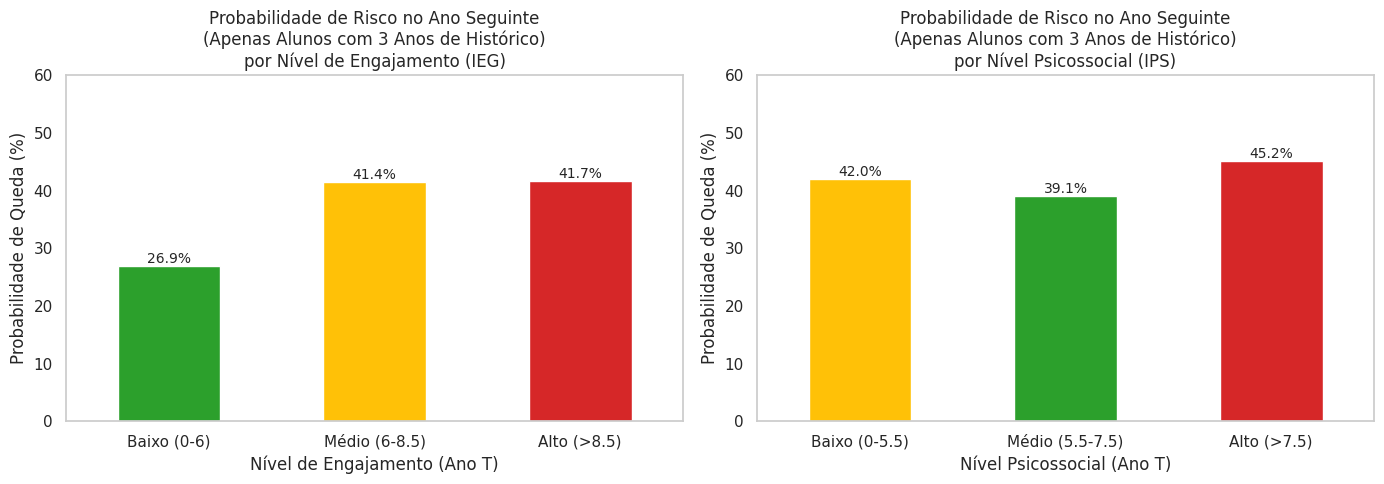

In [74]:
import pandas as pd
import numpy as np
import os

# Remover alunos onde IDA é igual a zero
df = df[df['IDA'] != 0].copy()

# Identificar RAs que têm registros nos 3 anos (2022, 2023 e 2024)
anos_estudo = [2022, 2023, 2024]
ra_counts = df[df['ANO'].isin(anos_estudo)].groupby('RA')['ANO'].nunique()
ra_3_anos = ra_counts[ra_counts == 3].index

# Filtrar apenas esses alunos
df_filtrado = df[df['RA'].isin(ra_3_anos)].sort_values(by=['RA', 'ANO'])

# Criar dataframe do Ano T+1
df_next = df_filtrado[['RA', 'ANO', 'IDA', 'DEFASAGEM', 'IAN']].copy()
df_next['ANO'] = df_next['ANO'] - 1  # Alinha Ano T com os resultados do Ano T+1
df_next = df_next.rename(columns={'IDA': 'IDA_next', 'DEFASAGEM': 'DEFASAGEM_next', 'IAN': 'IAN_next'})

# Mesclar
df_merged = pd.merge(df_filtrado, df_next, on=['RA', 'ANO'], how='inner')

# Definir o que é um "Aluno em Risco" no Ano T+1
# 1. Queda acadêmica severa (perdeu mais de 1 ponto no IDA)
df_merged['Queda_Severa_IDA'] = (df_merged['IDA_next'] - df_merged['IDA']) <= -1.0
# 2. Piora na defasagem (a defasagem ficou mais negativa)
df_merged['Piora_Defasagem'] = (df_merged['DEFASAGEM_next'] - df_merged['DEFASAGEM']) < 0

# Risco Geral = Qualquer uma das duas situações
df_merged['Em_Risco_Futuro'] = df_merged['Queda_Severa_IDA'] | df_merged['Piora_Defasagem']

print(f"--- Total de Alunos Únicos Retidos na Análise: {len(ra_3_anos)} ---")
print("--- Total de Transições Analisadas (22->23 e 23->24) ---")
print(df_merged['Em_Risco_Futuro'].value_counts())

# Perfil dos indicadores no Ano T para alunos que VÃO entrar em risco no T+1
analise_cols = ['IDA', 'IEG', 'IPS', 'IAA', 'IPP']
resumo_medias = df_merged.groupby('Em_Risco_Futuro')[analise_cols].mean().round(2)
print("\n--- Médias dos Indicadores no Ano T ---")
print(resumo_medias)

# Analisando a probabilidade de risco baseado em faixas de Engajamento (IEG)
df_merged['IEG_Faixa'] = pd.cut(df_merged['IEG'], bins=[-1, 5.9, 8.5, 11], labels=['Baixo (0-6)', 'Médio (6-8.5)', 'Alto (>8.5)'])
prob_risco_ieg = (df_merged.groupby('IEG_Faixa', observed=False)['Em_Risco_Futuro'].mean() * 100).round(1)
print("\n--- Probabilidade de Falha/Queda por Nível de Engajamento Prévio (%) ---")
print(prob_risco_ieg)

# Analisando a probabilidade de risco baseado no IPS
df_merged['IPS_Faixa'] = pd.cut(df_merged['IPS'], bins=[-1, 5.5, 7.5, 11], labels=['Baixo (0-5.5)', 'Médio (5.5-7.5)', 'Alto (>7.5)'])
prob_risco_ips = (df_merged.groupby('IPS_Faixa', observed=False)['Em_Risco_Futuro'].mean() * 100).round(1)

# Lógica de cores dinâmicas
def get_risk_colors(series):
    sorted_vals = sorted(series.values)
    colors = []
    for val in series:
        if val == sorted_vals[0]:
            colors.append('#2ca02c')  # Verde (Menor risco)
        elif val == sorted_vals[-1]:
            colors.append('#d62728')  # Vermelho (Maior risco)
        else:
            colors.append('#ffc107')  # Amarelo (Risco intermediário)
    return colors

cores_ieg = get_risk_colors(prob_risco_ieg)
cores_ips = get_risk_colors(prob_risco_ips)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Probabilidade por IEG
# IEG_Faixa: Baixo (25.9% risco), Médio (42.2% risco), Alto (42.0% risco)
# Mapeamento por risco: Baixo(25.9%)->Verde, Médio(42.2%)->Vermelho, Alto(42.0%)->Amarelo
prob_risco_ieg.plot(kind='bar', color=cores_ieg, ax=axes[0])
axes[0].set_title('Probabilidade de Risco no Ano Seguinte\n(Apenas Alunos com 3 Anos de Histórico)\npor Nível de Engajamento (IEG)')
axes[0].set_ylabel('Probabilidade de Queda (%)')
axes[0].set_xlabel('Nível de Engajamento (Ano T)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 60)
axes[0].grid(False)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()}%",(p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Gráfico 2: Probabilidade por IPS
# IPS_Faixa: Baixo (42.9% risco), Médio (39.1% risco), Alto (45.9% risco)
# Mapeamento por risco: Baixo(42.9%)->Amarelo, Médio(39.1%)->Verde, Alto(45.9%)->Vermelho
prob_risco_ips.plot(kind='bar', color=cores_ips, ax=axes[1])
axes[1].set_title('Probabilidade de Risco no Ano Seguinte\n(Apenas Alunos com 3 Anos de Histórico)\npor Nível Psicossocial (IPS)')
axes[1].set_ylabel('Probabilidade de Queda (%)')
axes[1].set_xlabel('Nível Psicossocial (Ano T)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 60)
axes[1].grid(False)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()}%",(p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('preditores_risco_3anos.png')

Ao analisar os dados obtidos no gráfico anterior, reparamos que a Fase 7 pode gerar "ruido" nos dados, visto que muitos alunos tem notas zeradas. Então refizemos a análise retirando os alunos da Fase 7 e outros que estão com IDA zerado

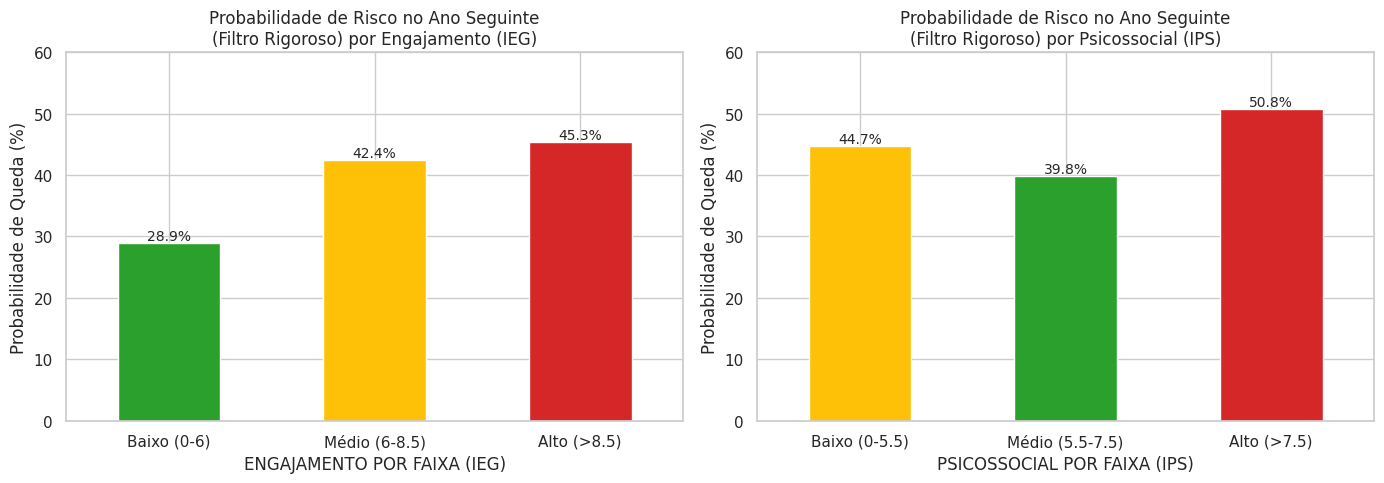

In [75]:
# Aplicar os filtros rigorosos (sem Fase 7, sem notas zeradas)
mask_zeradas = (df['MAT'] == 0) | (df['POR'] == 0) | (df['ING'] == 0)
df_clean = df[(df['FASE_ESCOLAR'] != 7) & (~mask_zeradas)].copy()

# Preditores de Risco (Cálculo)
df_next_risk = df_clean[['RA', 'ANO', 'IDA', 'DEFASAGEM']].copy()
df_next_risk['ANO'] = df_next_risk['ANO'] - 1  # Alinhamento
df_next_risk = df_next_risk.rename(columns={'IDA': 'IDA_next', 'DEFASAGEM': 'DEFASAGEM_next'})

df_merged_risk = pd.merge(df_clean, df_next_risk, on=['RA', 'ANO'], how='inner')
df_merged_risk['Em_Risco_Futuro'] = ((df_merged_risk['IDA_next'] - df_merged_risk['IDA']) <= -1.0) | ((df_merged_risk['DEFASAGEM_next'] - df_merged_risk['DEFASAGEM']) < 0)

df_merged_risk['IEG_Faixa'] = pd.cut(df_merged_risk['IEG'], bins=[-1, 5.9, 8.5, 11], labels=['Baixo (0-6)', 'Médio (6-8.5)', 'Alto (>8.5)'])
prob_risco_ieg = (df_merged_risk.groupby('IEG_Faixa', observed=True)['Em_Risco_Futuro'].mean() * 100).round(1)

df_merged_risk['IPS_Faixa'] = pd.cut(df_merged_risk['IPS'], bins=[-1, 5.5, 7.5, 11], labels=['Baixo (0-5.5)', 'Médio (5.5-7.5)', 'Alto (>7.5)'])
prob_risco_ips = (df_merged_risk.groupby('IPS_Faixa', observed=True)['Em_Risco_Futuro'].mean() * 100).round(1)

# Lógica de cores dinâmicas
def get_risk_colors(series):
    sorted_vals = sorted(series.values)
    colors = []
    for val in series:
        if val == sorted_vals[0]:
            colors.append('#2ca02c')  # Verde (Menor risco)
        elif val == sorted_vals[-1]:
            colors.append('#d62728')  # Vermelho (Maior risco)
        else:
            colors.append('#ffc107')  # Amarelo (Risco intermediário)
    return colors

cores_ieg = get_risk_colors(prob_risco_ieg)
cores_ips = get_risk_colors(prob_risco_ips)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico IEG
prob_risco_ieg.plot(kind='bar', color=cores_ieg, ax=axes[0])
axes[0].set_title('Probabilidade de Risco no Ano Seguinte\n(Filtro Rigoroso) por Engajamento (IEG)')
axes[0].set_ylabel('Probabilidade de Queda (%)')
axes[0].set_xlabel('ENGAJAMENTO POR FAIXA (IEG)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 60) # AUMENTADO PARA 60 PARA CABER O RÓTULO
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Gráfico IPS
prob_risco_ips.plot(kind='bar', color=cores_ips, ax=axes[1])
axes[1].set_title('Probabilidade de Risco no Ano Seguinte\n(Filtro Rigoroso) por Psicossocial (IPS)')
axes[1].set_ylabel('Probabilidade de Queda (%)')
axes[1].set_xlabel('PSICOSSOCIAL POR FAIXA (IPS)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 60) # AUMENTADO PARA 60 PARA CABER O RÓTULO
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('preditores_risco_ylim_corrigido.png')


# 10. Efetividade do programa

Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

--- Quantidade Absoluta de Alunos por Pedra e Ano ---
PEDRAANO  Quartzo  Agata  Ametista  Topazio
ANO                                        
2022          102    237       341      128
2023           71    240       375      228
2024           69    202       363      303



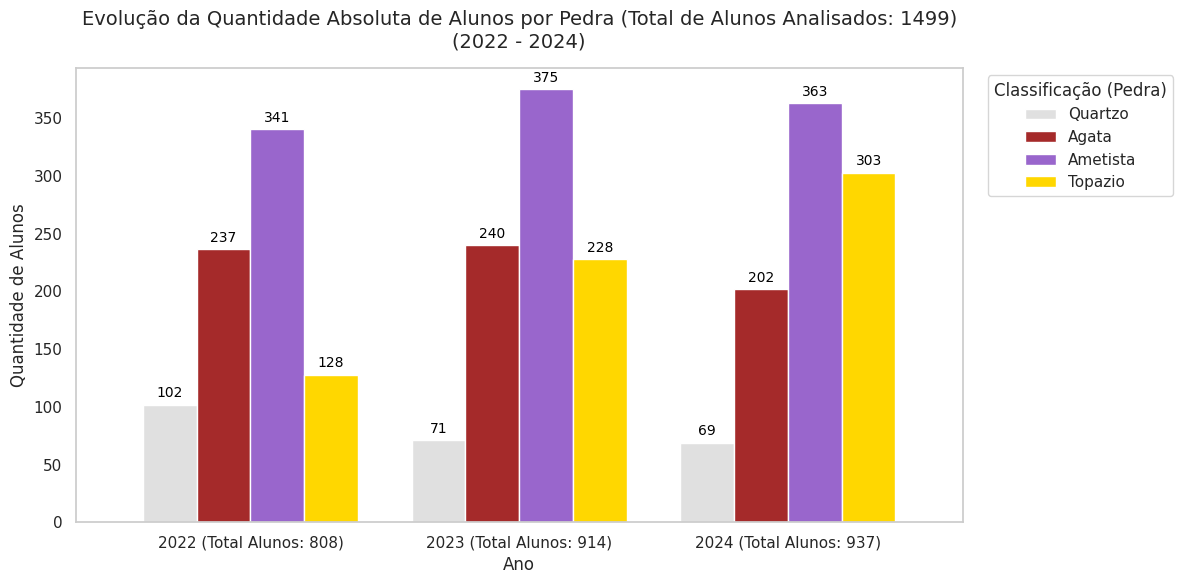

In [76]:
mask_zeradas = (df['MAT'] == 0) | (df['POR'] == 0) | (df['ING'] == 0)
df_clean = df[(df['FASE_ESCOLAR'] != 7) & (~mask_zeradas)].copy()

ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_clean['PEDRAANO'] = pd.Categorical(df_clean['PEDRAANO'], categories=ordem_pedras, ordered=True)

contagem_pedras = pd.crosstab(df_clean['ANO'], df_clean['PEDRAANO'])

print("--- Quantidade Absoluta de Alunos por Pedra e Ano ---")
print(contagem_pedras)
print("")

total_alunos_por_ano = contagem_pedras.sum(axis=1)

ax = contagem_pedras.plot(kind='bar', color=['#E0E0E0', '#A52A2A', '#9966CC', '#FFD700'], width=0.8, figsize=(12, 6))
fig = ax.figure # Obter o objeto Figure do objeto Axes

# Calculate total number of unique students (RA) from df_clean
total_alunos_analisados = df_clean['RA'].nunique()

plt.title(f'Evolução da Quantidade Absoluta de Alunos por Pedra (Total de Alunos Analisados: {total_alunos_analisados})\n(2022 - 2024)', fontsize=14, pad=15)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.xlabel('Ano', fontsize=12)

new_xticks = [f"{ano} (Total Alunos: {total_alunos_por_ano.loc[ano]})" for ano in contagem_pedras.index]
plt.xticks(ticks=range(len(new_xticks)), labels=new_xticks, rotation=0)

plt.legend(title='Classificação (Pedra)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(False)

for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(altura)}',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('evolucao_qtd_pedras.png')


Análise da evolução do indicador INDE considerando apenas os alunos que estiveram na escola nos 3 anos

--- Total de Alunos na Coorte Fixa: 374 ---
--- Quantidade Absoluta de Alunos por Pedra e Ano (Coorte de 3 Anos) ---
PEDRAANO  Quartzo  Agata  Ametista  Topazio
ANO                                        
2022           22     90       180       82
2023           25     97       156       96
2024           33     93       120      128


<Figure size 1200x600 with 0 Axes>

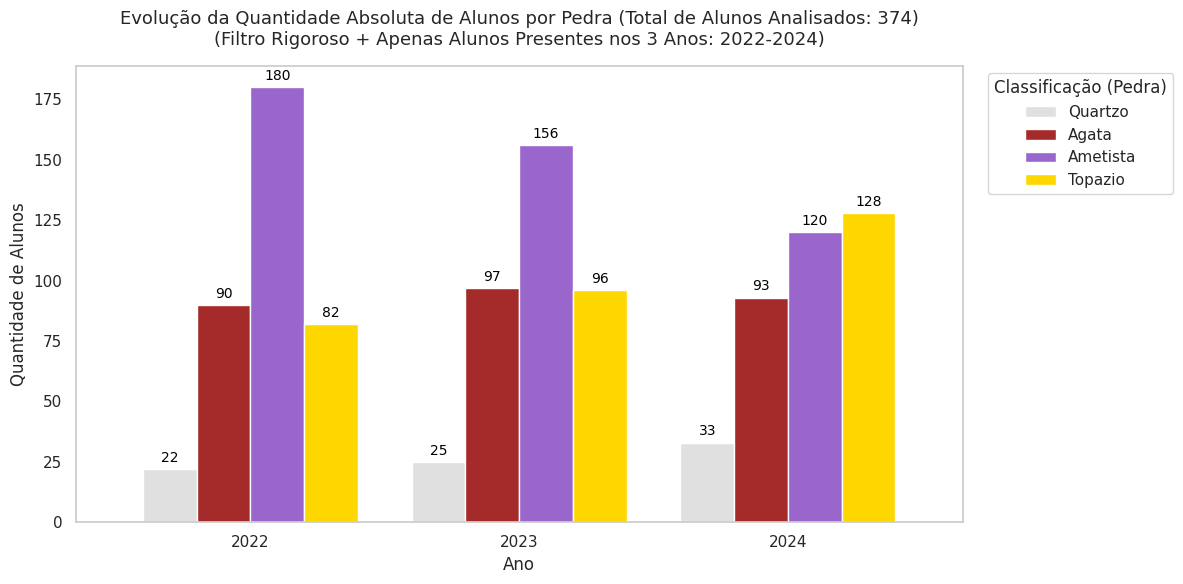

In [77]:
# Aplicar o filtro rigoroso
mask_zeradas = (df['MAT'] == 0) | (df['POR'] == 0) | (df['ING'] == 0)
df_clean = df[(df['FASE_ESCOLAR'] != 7) & (~mask_zeradas)].copy()

# Filtrar alunos que têm registros nos 3 anos (2022, 2023, 2024)
anos_estudo = [2022, 2023, 2024]
ra_counts = df_clean[df_clean['ANO'].isin(anos_estudo)].groupby('RA')['ANO'].nunique()
ra_3_anos = ra_counts[ra_counts == 3].index
df_3anos = df_clean[df_clean['RA'].isin(ra_3_anos)].copy()

# Ordenar as Pedras
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_3anos['PEDRAANO'] = pd.Categorical(df_3anos['PEDRAANO'], categories=ordem_pedras, ordered=True)

# Calcular a quantidade absoluta de alunos por Pedra e Ano
contagem_pedras = pd.crosstab(df_3anos['ANO'], df_3anos['PEDRAANO'])

# Calculate total number of unique students (RA) from df_clean
total_alunos_analisados = df_3anos['RA'].nunique()

print(f"--- Total de Alunos na Coorte Fixa: {len(ra_3_anos)} ---")
print("--- Quantidade Absoluta de Alunos por Pedra e Ano (Coorte de 3 Anos) ---")
print(contagem_pedras)

# Configurar o gráfico de barras agrupadas
plt.figure(figsize=(12, 6))
ax = contagem_pedras.plot(kind='bar', color=['#E0E0E0', '#A52A2A', '#9966CC', '#FFD700'], width=0.8, figsize=(12, 6))

plt.title(f'Evolução da Quantidade Absoluta de Alunos por Pedra (Total de Alunos Analisados: {total_alunos_analisados})\n(Filtro Rigoroso + Apenas Alunos Presentes nos 3 Anos: 2022-2024)', fontsize=13, pad=15)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Classificação (Pedra)', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(False)

# Adicionar os rótulos de dados (valores) em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(altura)}',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('evolucao_qtd_pedras_3anos_rigoroso.png')

## ANALISANDO SE EXISTE ALGUM VIÉS NA ESCOLHA DOS NOVOS ALUNOS

Qual a classificação (Pedra) dos alunos ao final do primeiro ano na Associação?

O objetivo aqui é identificar se para melhorar os indicadores, a Associação passou a fazer filtros de perfil para aceitar novos alunos

--- Quantidade de Alunos no Ano de Ingresso por Pedra ---
PEDRAANO  Quartzo  Agata  Ametista  Topazio
ANO                                        
2022           41    122       172       58
2023           19     78       153      109
2024           27     70       150       97

--- Total de ingressantes por ano ---
ANO
2022    393
2023    359
2024    344
Name: count, dtype: int64


<Figure size 1200x600 with 0 Axes>

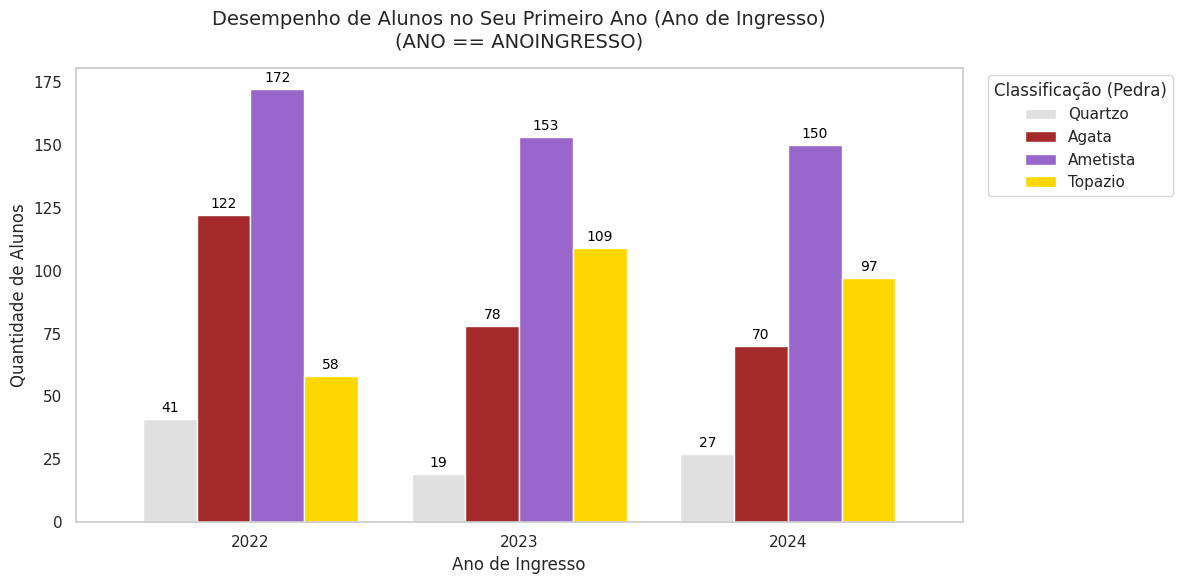

In [78]:
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# Ordenar as Pedras para o gráfico
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_ingressantes['PEDRAANO'] = pd.Categorical(df_ingressantes['PEDRAANO'], categories=ordem_pedras, ordered=True)

# Calcular a quantidade de alunos ingressantes por Pedra em cada ano
contagem_ingressantes = pd.crosstab(df_ingressantes['ANO'], df_ingressantes['PEDRAANO'])

print("--- Quantidade de Alunos no Ano de Ingresso por Pedra ---")
print(contagem_ingressantes)
print("\n--- Total de ingressantes por ano ---")
print(df_ingressantes['ANO'].value_counts().sort_index())

# Configurar o gráfico
plt.figure(figsize=(12, 6))
ax = contagem_ingressantes.plot(kind='bar', color=['#E0E0E0', '#A52A2A', '#9966CC', '#FFD700'], width=0.8, figsize=(12, 6))

plt.title('Desempenho de Alunos no Seu Primeiro Ano (Ano de Ingresso)\n(ANO == ANOINGRESSO)', fontsize=14, pad=15)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.xlabel('Ano de Ingresso', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Classificação (Pedra)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(False)

# Adicionar os rótulos de dados
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(altura)}',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('ingressantes_por_pedra.png')

### Análise da origem dos alunos da associação, particular ou privada

--- Quantidade de Alunos Ingressantes por Tipo de Instituição (Sem Concluído) ---
TIPOINSTITUICAO  PRIVADA  PÚBLICA
ANO                              
2022                   0      393
2023                   6      350
2024                   6      337


<Figure size 900x600 with 0 Axes>

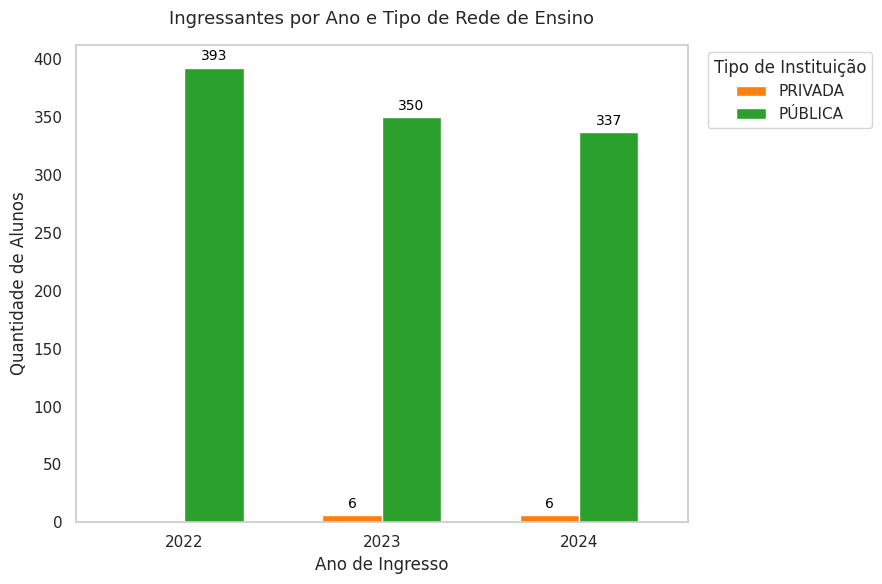

In [79]:
# Filtrar ingressantes (ANO == ANOINGRESSO)
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# Padronizar a coluna TIPOINSTITUICAO para evitar duplicações por erro de digitação
df_ingressantes['TIPOINSTITUICAO'] = df_ingressantes['TIPOINSTITUICAO'].fillna('Não Informado').astype(str).str.strip().str.upper()

# Retirar os alunos com status 'CONCLUIDO'
df_ingressantes_clean = df_ingressantes[df_ingressantes['TIPOINSTITUICAO'] != 'CONCLUIDO'].copy()

# Calcular a quantidade de alunos ingressantes por Tipo de Instituição em cada ano
contagem_inst = pd.crosstab(df_ingressantes_clean['ANO'], df_ingressantes_clean['TIPOINSTITUICAO'])

print("--- Quantidade de Alunos Ingressantes por Tipo de Instituição (Sem Concluído) ---")
print(contagem_inst)

# Definir paleta de cores para contraste (Laranja para Privada, Verde para Pública)
cores = ['#ff7f0e', '#2ca02c']

# Configurar o gráfico
plt.figure(figsize=(9, 6))
ax = contagem_inst.plot(kind='bar', color=cores, width=0.6, figsize=(9, 6))

plt.title('Ingressantes por Ano e Tipo de Rede de Ensino', fontsize=13, pad=15)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.xlabel('Ano de Ingresso', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Tipo de Instituição', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(False)

# Adicionar os rótulos de dados
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(altura)}',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('ingressantes_por_instituicao_sem_concluido.png')


### Análise da do perfil de gênero e etário dos alunos admitos em cada ano



GENERO  Feminino  Masculino
ANO                        
2022         191        202
2023         189        170
2024         189        155

--- Faixa Etária ---
FAIXA_ETARIA  7 a 10 anos  11 a 14 anos  15 a 18 anos  19+ anos
ANO                                                            
2022                  193           151            43         6
2023                  186           127            42         4
2024                  140           125            79         0

--- Média de Idade ---
      mean  median  min  max
ANO                         
2022  11.2    11.0    7   21
2023  10.9    10.0    7   22
2024  11.7    11.0    7   18


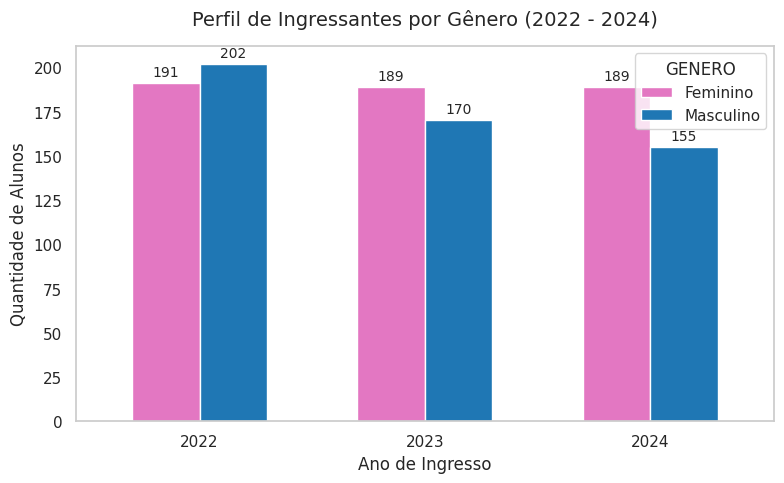

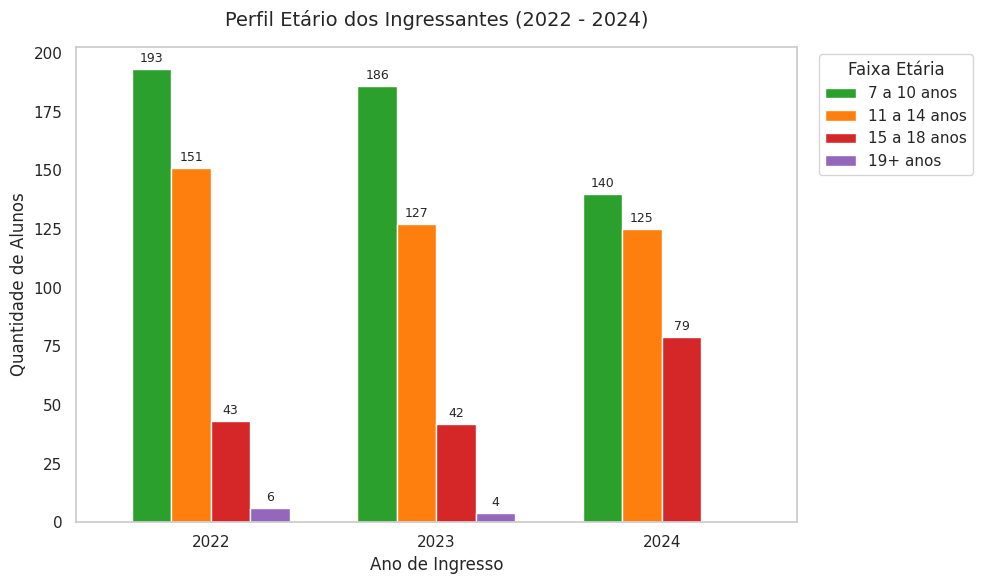

In [80]:
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# 1. Gráfico de Gênero
contagem_genero = pd.crosstab(df_ingressantes['ANO'], df_ingressantes['GENERO'])
fig_gen, ax_gen = plt.subplots(figsize=(8, 5))
contagem_genero.plot(kind='bar', color=['#e377c2', '#1f77b4'], ax=ax_gen, width=0.6)
ax_gen.set_title('Perfil de Ingressantes por Gênero (2022 - 2024)', fontsize=14, pad=15)
ax_gen.set_ylabel('Quantidade de Alunos', fontsize=12)
ax_gen.set_xlabel('Ano de Ingresso', fontsize=12)
ax_gen.tick_params(axis='x', rotation=0)
for p in ax_gen.patches:
    altura = p.get_height()
    if altura > 0:
        ax_gen.annotate(f'{int(altura)}', (p.get_x() + p.get_width() / 2., altura),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
ax_gen.grid(False)
plt.savefig('ingressantes_genero.png')

# 2. Gráfico de Idade (Faixas etárias)
bins = [0, 10, 14, 18, 100]
labels = ['7 a 10 anos', '11 a 14 anos', '15 a 18 anos', '19+ anos']
df_ingressantes['FAIXA_ETARIA'] = pd.cut(df_ingressantes['IDADEFINAL'], bins=bins, labels=labels, right=True)
contagem_idade = pd.crosstab(df_ingressantes['ANO'], df_ingressantes['FAIXA_ETARIA'])

fig_id, ax_id = plt.subplots(figsize=(10, 6))
contagem_idade.plot(kind='bar', color=['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'], ax=ax_id, width=0.7)
ax_id.set_title('Perfil Etário dos Ingressantes (2022 - 2024)', fontsize=14, pad=15)
ax_id.set_ylabel('Quantidade de Alunos', fontsize=12)
ax_id.set_xlabel('Ano de Ingresso', fontsize=12)
ax_id.tick_params(axis='x', rotation=0)
for p in ax_id.patches:
    altura = p.get_height()
    if altura > 0:
        ax_id.annotate(f'{int(altura)}', (p.get_x() + p.get_width() / 2., altura),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.legend(title='Faixa Etária', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
ax_id.grid(False)
plt.savefig('ingressantes_idade.png')

print(contagem_genero)
print("\n--- Faixa Etária ---")
print(contagem_idade)
print("\n--- Média de Idade ---")
print(df_ingressantes.groupby('ANO')['IDADEFINAL'].agg(['mean', 'median', 'min', 'max']).round(1))

### Analisando se houve alguma outra tendência na seleção de novos alunos ao longo dos anos

O objeto aqui foi cruzar a classificação (pedra) no ano de ingresso x faixa etária.

A análise completa está no documento executivo

--- Distribuição Percentual de Pedras por Faixa Etária (Todos os Ingressantes) ---
PEDRAANO      Quartzo  Agata  Ametista  Topazio
FAIXA_ETARIA                                   
7 a 10 anos       3.9   17.0      43.9     35.3
11 a 14 anos      9.7   30.3      44.7     15.4
15 a 18 anos     17.1   35.4      37.2     10.4
19+ anos          0.0   20.0      60.0     20.0

--- Distribuição Percentual de Pedras por Faixa Etária (Por Ano) ---

Ano 2022:
PEDRAANO      Quartzo  Agata  Ametista  Topazio
FAIXA_ETARIA                                   
7 a 10 anos       3.6   26.4      49.2     20.7
11 a 14 anos     13.9   33.8      41.7     10.6
15 a 18 anos     30.2   41.9      25.6      2.3
19+ anos          0.0   33.3      50.0     16.7

Ano 2023:
PEDRAANO      Quartzo  Agata  Ametista  Topazio
FAIXA_ETARIA                                   
7 a 10 anos       4.8   12.4      37.1     45.7
11 a 14 anos      4.7   30.7      49.6     15.0
15 a 18 anos      9.5   38.1      42.9      9.5
19+ anos 

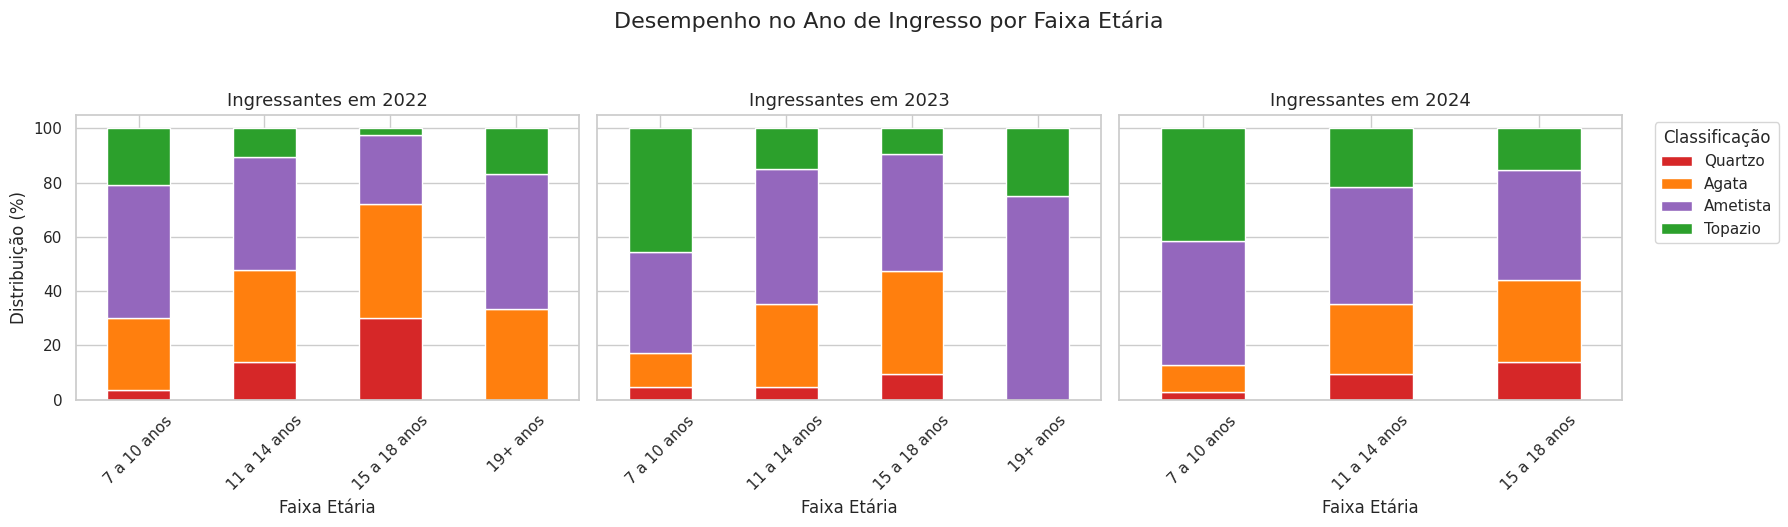

In [81]:

# Filtrar ingressantes
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# Criar Faixas Etárias
bins = [0, 10, 14, 18, 100]
labels = ['7 a 10 anos', '11 a 14 anos', '15 a 18 anos', '19+ anos']
df_ingressantes['FAIXA_ETARIA'] = pd.cut(df_ingressantes['IDADEFINAL'], bins=bins, labels=labels, right=True)

# Ordenar Pedras
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_ingressantes['PEDRAANO'] = pd.Categorical(df_ingressantes['PEDRAANO'], categories=ordem_pedras, ordered=True)

# Tabela cruzada: Faixa Etária x Pedra (Geral)
crosstab_geral = pd.crosstab(df_ingressantes['FAIXA_ETARIA'], df_ingressantes['PEDRAANO'], normalize='index') * 100

print("--- Distribuição Percentual de Pedras por Faixa Etária (Todos os Ingressantes) ---")
print(crosstab_geral.round(1))

# Tabela cruzada: Faixa Etária x Pedra por ANO
print("\n--- Distribuição Percentual de Pedras por Faixa Etária (Por Ano) ---")
for ano in [2022, 2023, 2024]:
    df_ano = df_ingressantes[df_ingressantes['ANO'] == ano]
    ct_ano = pd.crosstab(df_ano['FAIXA_ETARIA'], df_ano['PEDRAANO'], normalize='index') * 100
    print(f"\nAno {ano}:")
    print(ct_ano.round(1))

# Vamos focar na faixa de 15 a 18 anos vs 7 a 10 anos para ver se há viés de "alta performance" nos mais velhos
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

cores_pedras = ['#d62728', '#ff7f0e', '#9467bd', '#2ca02c']

for i, ano in enumerate([2022, 2023, 2024]):
    df_ano = df_ingressantes[df_ingressantes['ANO'] == ano]
    ct_ano = pd.crosstab(df_ano['FAIXA_ETARIA'], df_ano['PEDRAANO'], normalize='index') * 100

    ct_ano.plot(kind='bar', stacked=True, color=cores_pedras, ax=axes[i], legend=False)
    axes[i].set_title(f'Ingressantes em {ano}', fontsize=13)
    axes[i].set_xlabel('Faixa Etária')
    axes[i].tick_params(axis='x', rotation=45)

    if i == 0:
        axes[i].set_ylabel('Distribuição (%)')

# Adicionar legenda no último gráfico
axes[2].legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Desempenho no Ano de Ingresso por Faixa Etária ', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('vies_idade_pedra.png')
print("\nGráfico salvo como vies_idade_pedra.png")

Como o gráfico de barras ficou confuso, optamos por reescrever a lógica separando um gráfico para cada ano

--- Distribuição Percentual de Pedras por Faixa Etária (Todos os Ingressantes) ---
PEDRAANO      Quartzo  Agata  Ametista  Topazio
FAIXA_ETARIA                                   
7 a 10 anos       3.9   17.0      43.9     35.3
11 a 14 anos      9.7   30.3      44.7     15.4
15 a 18 anos     17.1   35.4      37.2     10.4
19+ anos          0.0   20.0      60.0     20.0

--- Distribuição Percentual de Pedras por Faixa Etária (Por Ano) ---

Ano 2022:
PEDRAANO      Quartzo  Agata  Ametista  Topazio
FAIXA_ETARIA                                   
7 a 10 anos       3.6   26.4      49.2     20.7
11 a 14 anos     13.9   33.8      41.7     10.6
15 a 18 anos     30.2   41.9      25.6      2.3
19+ anos          0.0   33.3      50.0     16.7


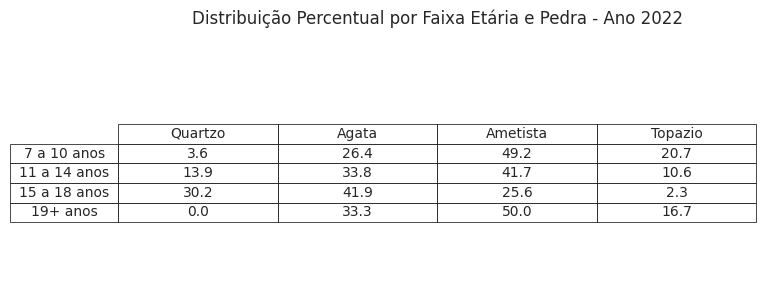


Ano 2023:
PEDRAANO      Quartzo  Agata  Ametista  Topazio
FAIXA_ETARIA                                   
7 a 10 anos       4.8   12.4      37.1     45.7
11 a 14 anos      4.7   30.7      49.6     15.0
15 a 18 anos      9.5   38.1      42.9      9.5
19+ anos          0.0    0.0      75.0     25.0


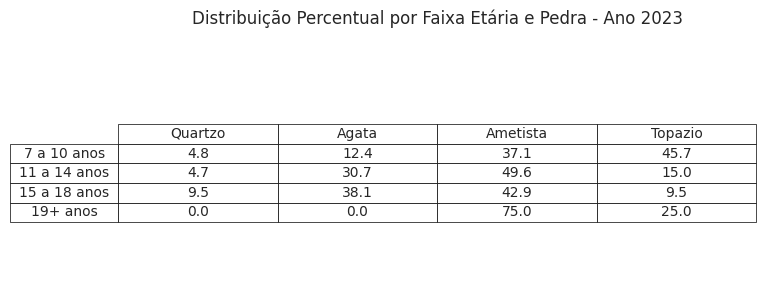


Ano 2024:
PEDRAANO      Quartzo  Agata  Ametista  Topazio
FAIXA_ETARIA                                   
7 a 10 anos       2.9   10.0      45.7     41.4
11 a 14 anos      9.6   25.6      43.2     21.6
15 a 18 anos     13.9   30.4      40.5     15.2


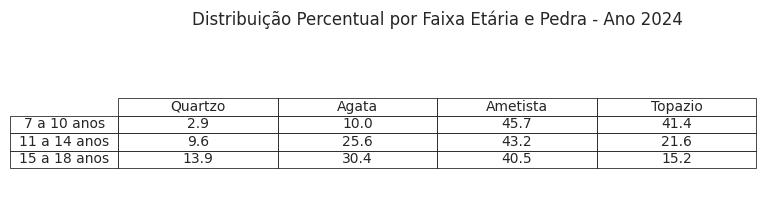

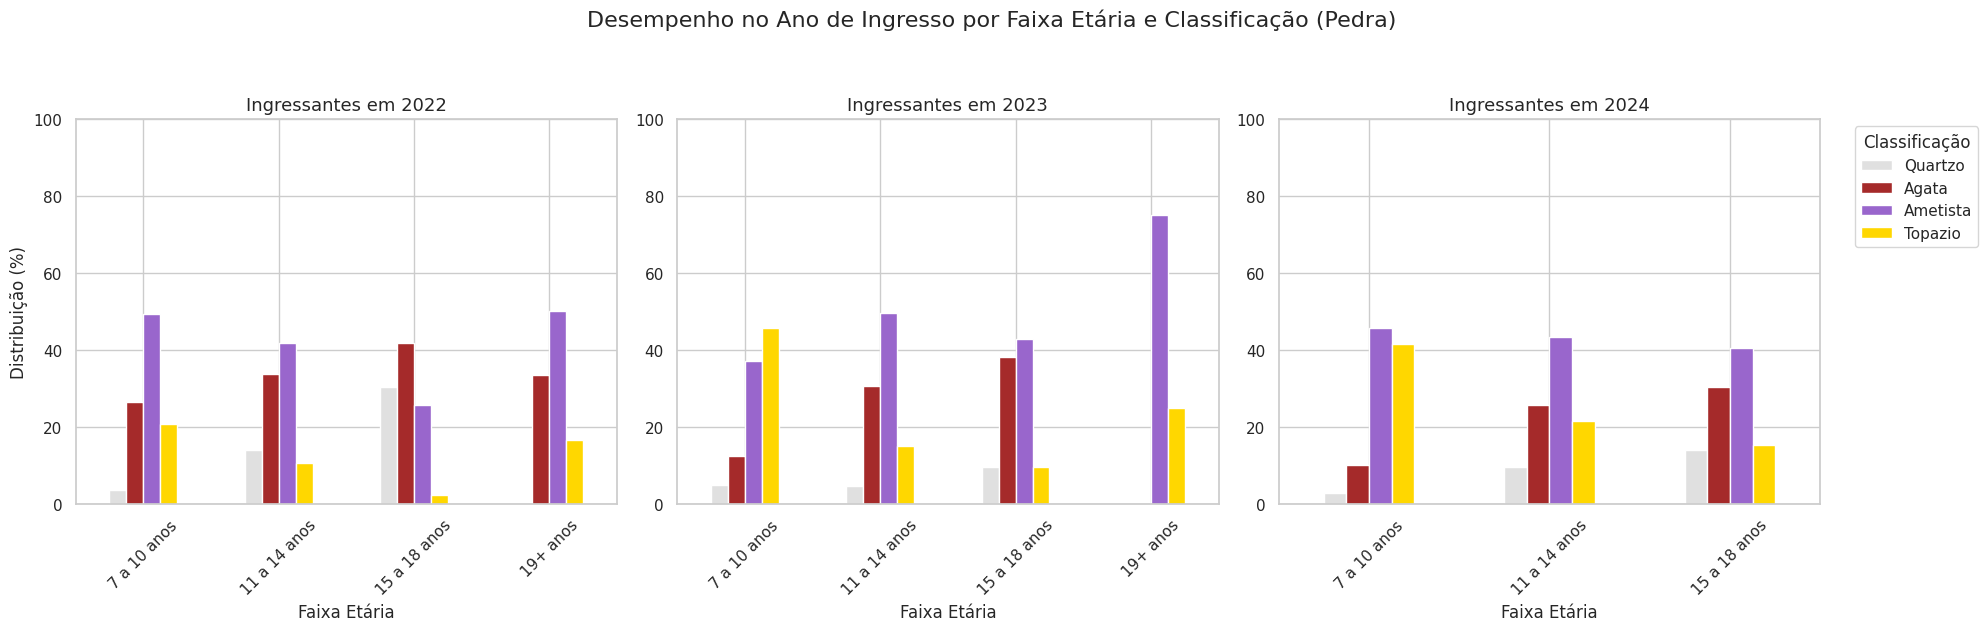

In [82]:

# Filtrar ingressantes
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# Criar Faixas Etárias
bins = [0, 10, 14, 18, 100]
labels = ['7 a 10 anos', '11 a 14 anos', '15 a 18 anos', '19+ anos']
df_ingressantes['FAIXA_ETARIA'] = pd.cut(df_ingressantes['IDADEFINAL'], bins=bins, labels=labels, right=True)

# Ordenar Pedras
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_ingressantes['PEDRAANO'] = pd.Categorical(df_ingressantes['PEDRAANO'], categories=ordem_pedras, ordered=True)

# Tabela cruzada: Faixa Etária x Pedra (Geral)
crosstab_geral = pd.crosstab(df_ingressantes['FAIXA_ETARIA'], df_ingressantes['PEDRAANO'], normalize='index') * 100

print("--- Distribuição Percentual de Pedras por Faixa Etária (Todos os Ingressantes) ---")
print(crosstab_geral.round(1))

# Tabela cruzada: Faixa Etária x Pedra por ANO
print("\n--- Distribuição Percentual de Pedras por Faixa Etária (Por Ano) ---")
for ano in [2022, 2023, 2024]:
    df_ano = df_ingressantes[df_ingressantes['ANO'] == ano]
    ct_ano = pd.crosstab(df_ano['FAIXA_ETARIA'], df_ano['PEDRAANO'], normalize='index') * 100
    print(f"\nAno {ano}:")
    print(ct_ano.round(1))

    # Display the percentage distribution table with vertical and horizontal lines
    fig_table, ax_table = plt.subplots(figsize=(8, len(ct_ano) * 0.8)) # Adjust figure size dynamically
    ax_table.set_title(f'Distribuição Percentual por Faixa Etária e Pedra - Ano {ano}', fontsize=12, pad=20)
    ax_table.axis('off') # Hide axes

    table = ax_table.table(cellText=ct_ano.round(1).values, colLabels=ct_ano.columns,
                           rowLabels=ct_ano.index, loc='center', cellLoc='center', rowLoc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    # Apply grid lines to cells
    for (i, j), cell in table.get_celld().items():
        cell.set_edgecolor('black')
        cell.set_linewidth(0.5)

    plt.tight_layout()
    plt.savefig(f'distribuicao_percentual_pedra_faixa_etaria_ano_{ano}.png')
    plt.show()


# Vamos focar na faixa de 15 a 18 anos vs 7 a 10 anos para ver se há viés de "alta performance" nos mais velhos
# Criando um subplot para cada ano, com gráfico de barras agrupadas
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # Aumentei a largura para barras agrupadas

cores_pedras_dict = {
    'Quartzo': '#E0E0E0',
    'Agata': '#A52A2A',
    'Ametista':'#9966CC',
    'Topazio': '#FFD700'
}

for i, ano in enumerate([2022, 2023, 2024]):
    df_ano = df_ingressantes[df_ingressantes['ANO'] == ano]
    ct_ano = pd.crosstab(df_ano['FAIXA_ETARIA'], df_ano['PEDRAANO'], normalize='index') * 100

    # Garantir que todas as pedras estejam presentes nas colunas do dataframe para plotagem consistente
    # Preencher colunas ausentes com 0 se um tipo de pedra não aparecer para um determinado grupo etário em um ano
    for pedra in ordem_pedras:
        if pedra not in ct_ano.columns:
            ct_ano[pedra] = 0

    # Ordenar colunas por `ordem_pedras` para garantir mapeamento de cores consistente
    ct_ano = ct_ano[ordem_pedras]

    # Plotar como gráfico de barras agrupadas (stacked=False)
    ct_ano.plot(kind='bar', stacked=False, color=[cores_pedras_dict[pedra] for pedra in ct_ano.columns], ax=axes[i], legend=False)

    axes[i].set_title(f'Ingressantes em {ano}', fontsize=13)
    axes[i].set_xlabel('Faixa Etária')
    axes[i].set_ylabel('Distribuição (%)' if i == 0 else '') # Mostrar rótulo y apenas para o primeiro gráfico
    axes[i].tick_params(axis='x', rotation=45) # Manter rotação pois as faixas etárias podem ser longas
    axes[i].set_ylim(0, 100) # Garantir que o eixo y seja de 0-100 para porcentagens
    # Removed the grid line setting

# Adicionar legenda no último gráfico (usando as cores consistentes)
handles, labels = axes[0].get_legend_handles_labels() # Obter alças/rótulos de um dos gráficos
axes[2].legend(handles=handles, labels=ordem_pedras, title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Desempenho no Ano de Ingresso por Faixa Etária e Classificação (Pedra)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('vies_idade_pedra_bar_agrupado_por_ano.png') # Nome do arquivo alterado para refletir o gráfico de barras agrupadas por ano


### Apenas repetindo a lógica anterior, mas separando em gráficos distintos para colar na documentação executiva.

##PERFIL ETÁRIO X PEDRA - ALUNOS QUE INGRESSARAM EM 2022

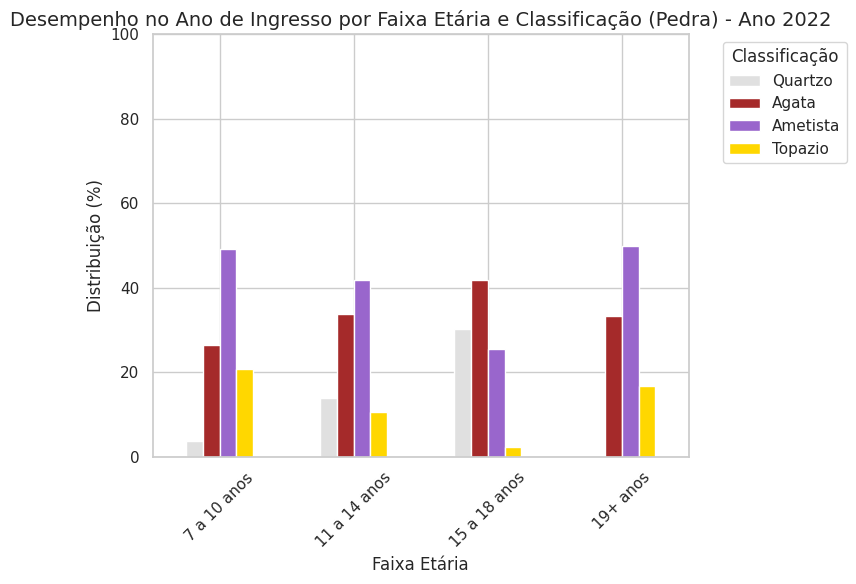

In [83]:
# Filtrar ingressantes
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# Criar Faixas Etárias
bins = [0, 10, 14, 18, 100]
labels = ['7 a 10 anos', '11 a 14 anos', '15 a 18 anos', '19+ anos']
df_ingressantes['FAIXA_ETARIA'] = pd.cut(df_ingressantes['IDADEFINAL'], bins=bins, labels=labels, right=True)

# Ordenar Pedras
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_ingressantes['PEDRAANO'] = pd.Categorical(df_ingressantes['PEDRAANO'], categories=ordem_pedras, ordered=True)

cores_pedras_dict = {
    'Quartzo': '#E0E0E0',
    'Agata': '#A52A2A',
    'Ametista':'#9966CC',
    'Topazio': '#FFD700'
}

# Gráfico para o Ano 2022
fig, ax = plt.subplots(figsize=(8, 6)) # Ajustei o tamanho para um único gráfico

df_ano_2022 = df_ingressantes[df_ingressantes['ANO'] == 2022]
ct_ano_2022 = pd.crosstab(df_ano_2022['FAIXA_ETARIA'], df_ano_2022['PEDRAANO'], normalize='index') * 100

# Garantir que todas as pedras estejam presentes nas colunas do dataframe para plotagem consistente
for pedra in ordem_pedras:
    if pedra not in ct_ano_2022.columns:
        ct_ano_2022[pedra] = 0
ct_ano_2022 = ct_ano_2022[ordem_pedras]

ct_ano_2022.plot(kind='bar', stacked=False, color=[cores_pedras_dict[pedra] for pedra in ct_ano_2022.columns], ax=ax)
ax.set_title('Desempenho no Ano de Ingresso por Faixa Etária e Classificação (Pedra) - Ano 2022', fontsize=14)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Distribuição (%)')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 100)
# ax.grid(axis='y', linestyle='--', alpha=0.7) # Linha de grade removida
ax.legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('vies_idade_pedra_bar_agrupado_2022.png')


##PERFIL ETÁRIO X PEDRA - ALUNOS QUE INGRESSARAM EM 2023

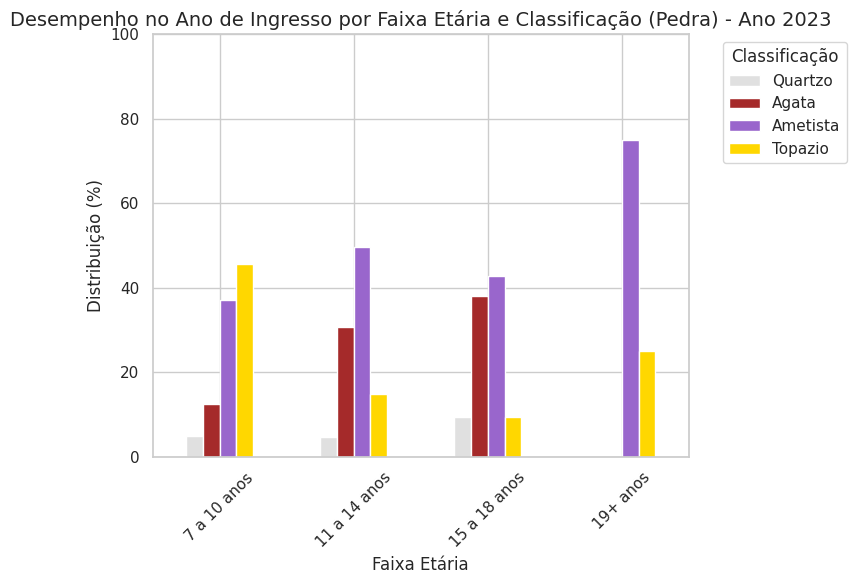

In [84]:
# Filtrar ingressantes
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# Criar Faixas Etárias
bins = [0, 10, 14, 18, 100]
labels = ['7 a 10 anos', '11 a 14 anos', '15 a 18 anos', '19+ anos']
df_ingressantes['FAIXA_ETARIA'] = pd.cut(df_ingressantes['IDADEFINAL'], bins=bins, labels=labels, right=True)

# Ordenar Pedras
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_ingressantes['PEDRAANO'] = pd.Categorical(df_ingressantes['PEDRAANO'], categories=ordem_pedras, ordered=True)

cores_pedras_dict = {
    'Quartzo': '#E0E0E0',
    'Agata': '#A52A2A',
    'Ametista':'#9966CC',
    'Topazio': '#FFD700'
}

# Gráfico para o Ano 2023
fig, ax = plt.subplots(figsize=(8, 6)) # Ajustei o tamanho para um único gráfico

df_ano_2023 = df_ingressantes[df_ingressantes['ANO'] == 2023]
ct_ano_2023 = pd.crosstab(df_ano_2023['FAIXA_ETARIA'], df_ano_2023['PEDRAANO'], normalize='index') * 100

# Garantir que todas as pedras estejam presentes nas colunas do dataframe para plotagem consistente
for pedra in ordem_pedras:
    if pedra not in ct_ano_2023.columns:
        ct_ano_2023[pedra] = 0
ct_ano_2023 = ct_ano_2023[ordem_pedras]

ct_ano_2023.plot(kind='bar', stacked=False, color=[cores_pedras_dict[pedra] for pedra in ct_ano_2023.columns], ax=ax)
ax.set_title('Desempenho no Ano de Ingresso por Faixa Etária e Classificação (Pedra) - Ano 2023', fontsize=14)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Distribuição (%)')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 100)
# ax.grid(axis='y', linestyle='--', alpha=0.7) # Linha de grade removida
ax.legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('vies_idade_pedra_bar_agrupado_2023.png')


##PERFIL ETÁRIO X PEDRA - ALUNOS QUE INGRESSARAM EM 2024

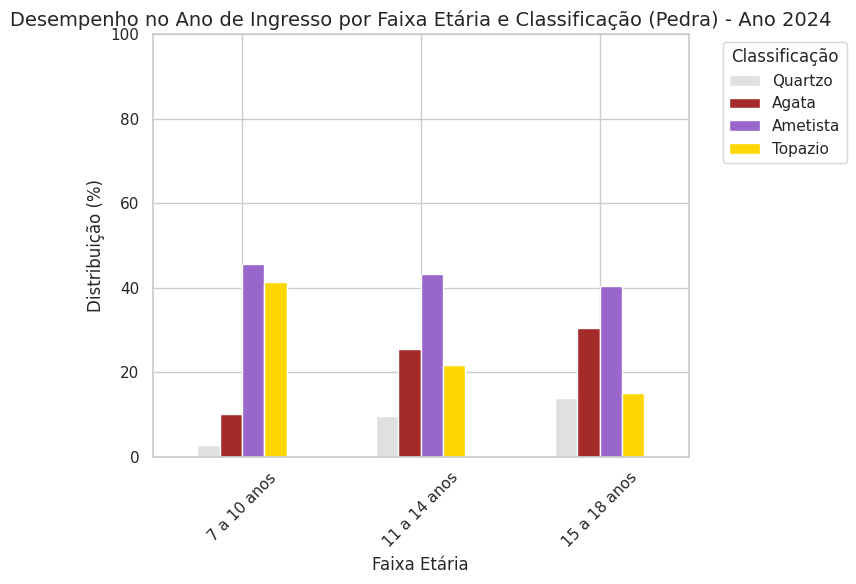

In [85]:
# Filtrar ingressantes
df_ingressantes = df[df['ANO'] == df['ANOINGRESSO']].copy()

# Criar Faixas Etárias
bins = [0, 10, 14, 18, 100]
labels = ['7 a 10 anos', '11 a 14 anos', '15 a 18 anos', '19+ anos']
df_ingressantes['FAIXA_ETARIA'] = pd.cut(df_ingressantes['IDADEFINAL'], bins=bins, labels=labels, right=True)

# Ordenar Pedras
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
df_ingressantes['PEDRAANO'] = pd.Categorical(df_ingressantes['PEDRAANO'], categories=ordem_pedras, ordered=True)

cores_pedras_dict = {
    'Quartzo': '#E0E0E0',
    'Agata': '#A52A2A',
    'Ametista':'#9966CC',
    'Topazio': '#FFD700'
}

# Gráfico para o Ano 2024
fig, ax = plt.subplots(figsize=(8, 6)) # Ajustei o tamanho para um único gráfico

df_ano_2024 = df_ingressantes[df_ingressantes['ANO'] == 2024]
ct_ano_2024 = pd.crosstab(df_ano_2024['FAIXA_ETARIA'], df_ano_2024['PEDRAANO'], normalize='index') * 100

# Garantir que todas as pedras estejam presentes nas colunas do dataframe para plotagem consistente
for pedra in ordem_pedras:
    if pedra not in ct_ano_2024.columns:
        ct_ano_2024[pedra] = 0
ct_ano_2024 = ct_ano_2024[ordem_pedras]

ct_ano_2024.plot(kind='bar', stacked=False, color=[cores_pedras_dict[pedra] for pedra in ct_ano_2024.columns], ax=ax)
ax.set_title('Desempenho no Ano de Ingresso por Faixa Etária e Classificação (Pedra) - Ano 2024', fontsize=14)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Distribuição (%)')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 100)
# ax.grid(axis='y', linestyle='--', alpha=0.7) # Linha de grade removida
ax.legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('vies_idade_pedra_bar_agrupado_2024.png')


# CONSTRUÇÃO DO MODELO PREDITIVO

Esta parte do código pode ser executada independente do que foi feito até aqui.

###Decidimos utilizar a PEDRA como "target", pois ela tem uma visibilidade muito grande nas documentações da Associação.

A separação dos para treino e testes foi feita da seguinte maneira:

2022 - Treino;
2023 - Teste;
2024 - Usado para verificar acurácia


Fizemos um primeiro modelo utilizando os dados de 2022 e 2023 como treino. Porém, como o indice IPP não existe nos dados de 2022, retiramos ele da fórmula de cálculo do INDE, distribuindo os 10% do peso dele proporcionalmente nos demais indicadores.

--- RELATÓRIO DE CLASSIFICAÇÃO (ACURÁCIA, RECALL, F1-SCORE) ---
              precision    recall  f1-score   support

       Agata       0.47      0.59      0.52       145
    Ametista       0.58      0.52      0.55       279
     Quartzo       0.14      0.08      0.11        24
     Topazio       0.53      0.55      0.54       157

    accuracy                           0.53       605
   macro avg       0.43      0.43      0.43       605
weighted avg       0.52      0.53      0.52       605


Visualizações salvas com sucesso no arquivo 'metricas_modelo.png'.
Treinamento de produção finalizado. Modelo exportado com sucesso!


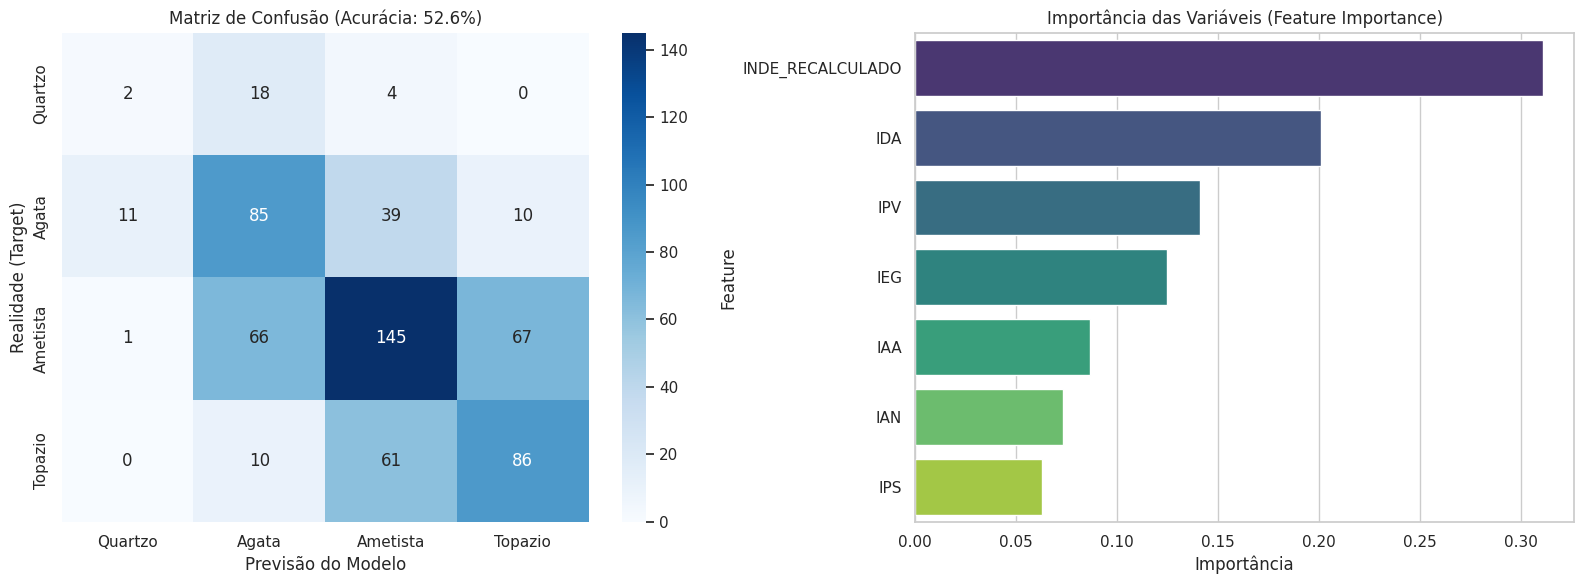

In [86]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ---------------------------------------------------------
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# ---------------------------------------------------------
url_excel = "https://raw.githubusercontent.com/LuciAguiar/DataThon/main/BASE_CONSOLIDADA.xlsx"
df = pd.read_excel(url_excel, sheet_name='Sheet1')

# Filtro rigoroso: Remover alunos da fase 7 e alunos com notas zeradas nas matérias-base
mask_zeradas = (df['MAT'] == 0) | (df['POR'] == 0) | (df['ING'] == 0)
df_clean = df[(df['FASE_ESCOLAR'] != 7) & (~mask_zeradas)].copy()

# ---------------------------------------------------------
# 2. ENGENHARIA DE ATRIBUTOS (FEATURE ENGINEERING)
# ---------------------------------------------------------
# Recálculo do INDE distribuindo os 10% do IPP proporcionalmente
pesos_novos = {
    'IAN': 0.1111, 'IDA': 0.2222, 'IEG': 0.2222,
    'IAA': 0.1111, 'IPS': 0.1111, 'IPV': 0.2222
}

for col in pesos_novos.keys():
    df_clean[col] = df_clean[col].fillna(0)

# Criar a feature de inércia acadêmica
df_clean['INDE_RECALCULADO'] = sum(df_clean[col] * peso for col, peso in pesos_novos.items())

# ---------------------------------------------------------
# 3. PREPARAÇÃO DO TARGET LONGITUDINAL (T -> T+1)
# ---------------------------------------------------------
df_next = df_clean[['RA', 'ANO', 'INDE_RECALCULADO']].copy()
df_next['ANO'] = df_next['ANO'] - 1
df_next = df_next.rename(columns={'INDE_RECALCULADO': 'INDE_next'})

# Unificar a base com o alvo
df_merged = pd.merge(df_clean, df_next, on=['RA', 'ANO'], how='inner')

# Função para converter INDE futuro em Categorias (Pedras)
def classificar_pedra(inde):
    if inde <= 5.506: return 'Quartzo'
    elif inde <= 6.868: return 'Agata'
    elif inde <= 8.230: return 'Ametista'
    else: return 'Topazio'

df_merged['PEDRA_next'] = df_merged['INDE_next'].apply(classificar_pedra)

# ---------------------------------------------------------
# 4. DEFINIÇÃO DE FEATURES E DIVISÃO TREINO/TESTE (CRONOLÓGICO)
# ---------------------------------------------------------
features = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE_RECALCULADO']
df_model = df_merged[['ANO', 'PEDRA_next'] + features].dropna()

# Separar dados temporalmente (Treino = 2022, Teste = 2023)
train_data = df_model[df_model['ANO'] == 2022]
test_data = df_model[df_model['ANO'] == 2023]

X_train = train_data[features]
y_train = train_data['PEDRA_next']

X_test = test_data[features]
y_test = test_data['PEDRA_next']

# SMOTE: Aplicado estritamente nos dados de treino (2022)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Para o treinamento final de produção, mantemos a lógica de juntar tudo
X = df_model[features]
y = df_model['PEDRA_next']

# ---------------------------------------------------------
# 5. AVALIAÇÃO DO MODELO E VISUALIZAÇÃO DE MÉTRICAS
# ---------------------------------------------------------
modelo_aval = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
modelo_aval.fit(X_train_smote, y_train_smote)

y_pred = modelo_aval.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print("--- RELATÓRIO DE CLASSIFICAÇÃO (ACURÁCIA, RECALL, F1-SCORE) ---")
print(classification_report(y_test, y_pred))

# Gerar Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']

# Gráfico 1: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=ordem_pedras)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordem_pedras, yticklabels=ordem_pedras, ax=axes[0])
axes[0].set_title(f'Matriz de Confusão (Acurácia: {acuracia*100:.1f}%)')
axes[0].set_xlabel('Previsão do Modelo')
axes[0].set_ylabel('Realidade (Target)')

# Gráfico 2: Importância das Variáveis
importances = modelo_aval.feature_importances_
df_imp = pd.DataFrame({'Feature': features, 'Importância': importances}).sort_values('Importância', ascending=False)
sns.barplot(x='Importância', y='Feature', data=df_imp, palette='viridis', hue='Feature', legend=False, ax=axes[1])
axes[1].set_title('Importância das Variáveis (Feature Importance)')

plt.tight_layout()
plt.savefig('metricas_modelo.png')
print("\nVisualizações salvas com sucesso no arquivo 'metricas_modelo.png'.")

# ---------------------------------------------------------
# 6. TREINAMENTO FINAL E EXPORTAÇÃO (DEPLOY)
# ---------------------------------------------------------
# Retreinar utilizando 100% da base tratada para produção
X_smote_full, y_smote_full = smote.fit_resample(X, y)
modelo_final = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
modelo_final.fit(X_smote_full, y_smote_full)

joblib.dump(modelo_final, 'modelo_passos_magicos.pkl')
print("Treinamento de produção finalizado. Modelo exportado com sucesso!")

### REAVALIDAÇÃO DO USO DO IPP

Como o indice IPP foi identificado como tendo uma forte influência no resultado geral do aluno, construímos um novo modelo considerando apenas o ano de 2023 para treinamento do modelo, para fins comparativos.

--- RELATÓRIO DE CLASSIFICAÇÃO (ACURÁCIA: 53.7%) ---
              precision    recall  f1-score   support

       Agata       0.45      0.54      0.49        28
    Ametista       0.61      0.43      0.51        58
     Quartzo       0.20      0.40      0.27         5
     Topazio       0.62      0.77      0.69        30

    accuracy                           0.54       121
   macro avg       0.47      0.53      0.49       121
weighted avg       0.56      0.54      0.54       121


Visualizações salvas com sucesso no arquivo 'metricas_modelo_atualizado.png'.
Treinamento de produção finalizado. Modelo exportado com sucesso!


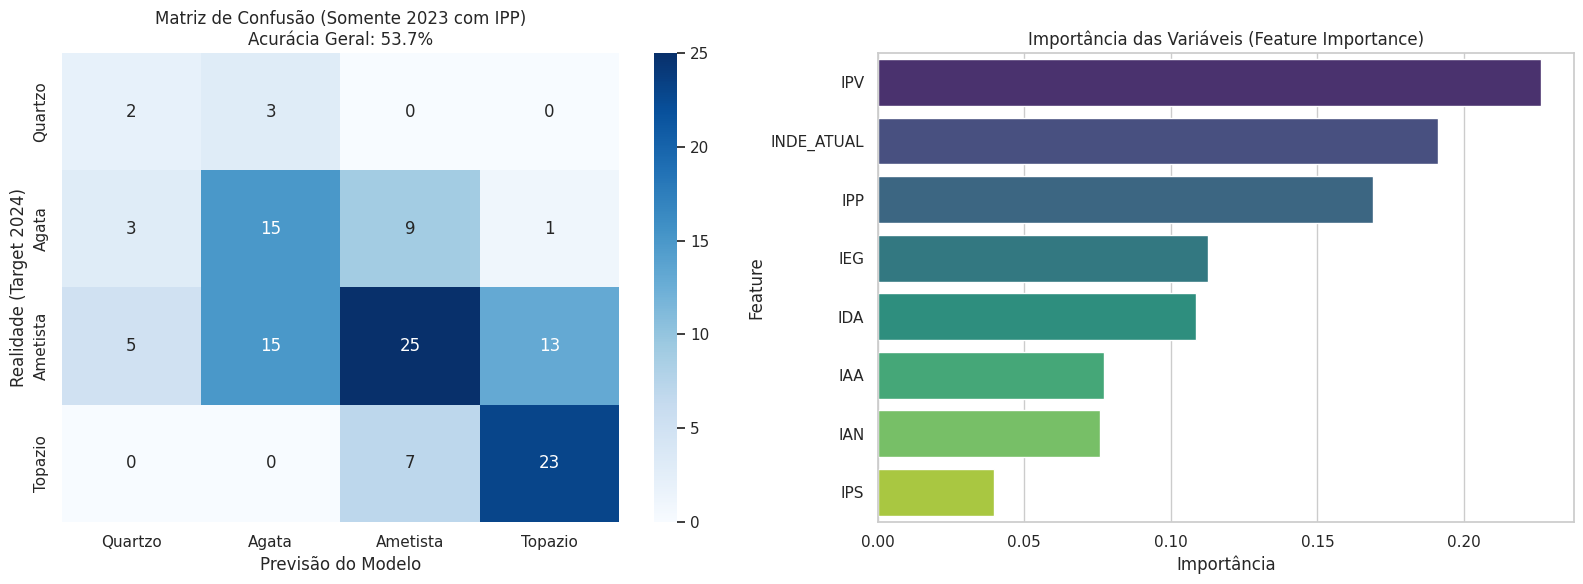

In [87]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ---------------------------------------------------------
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# ---------------------------------------------------------
url_excel = "https://raw.githubusercontent.com/LuciAguiar/DataThon/main/BASE_CONSOLIDADA.xlsx"
df = pd.read_excel(url_excel, sheet_name='Sheet1')

# Filtro rigoroso: Remover alunos da fase 7 e alunos com notas zeradas nas matérias-base
mask_zeradas = (df['MAT'] == 0) | (df['POR'] == 0) | (df['ING'] == 0)
df_clean = df[(df['FASE_ESCOLAR'] != 7) & (~mask_zeradas)].copy()

# ---------------------------------------------------------
# 2. ENGENHARIA DE ATRIBUTOS (COM IPP)
# ---------------------------------------------------------
features_oficiais = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IPP']

# Preencher possíveis valores nulos com zero
for col in features_oficiais:
    df_clean[col] = df_clean[col].fillna(0)

# Cálculo do INDE Oficial (com os 10% do IPP)
pesos = {'IAN': 0.1, 'IDA': 0.2, 'IEG': 0.2, 'IAA': 0.1, 'IPS': 0.1, 'IPV': 0.2, 'IPP': 0.1}
df_clean['INDE_ATUAL'] = sum(df_clean[col] * peso for col, peso in pesos.items())

# ---------------------------------------------------------
# 3. SETUP LONGITUDINAL E FILTRO TEMPORAL (2023 -> 2024)
# ---------------------------------------------------------
df_next = df_clean[['RA', 'ANO', 'INDE_ATUAL']].copy()
df_next['ANO'] = df_next['ANO'] - 1
df_next = df_next.rename(columns={'INDE_ATUAL': 'INDE_next'})

# Unificar a base com o alvo
df_merged = pd.merge(df_clean, df_next, on=['RA', 'ANO'], how='inner')

# EXCLUSÃO DE 2022: Isolar apenas a transição do ano de 2023 prevendo 2024
df_model = df_merged[df_merged['ANO'] == 2023].copy()

# Função de discretização para converter INDE futuro em Categorias (Pedras)
def classificar_pedra(inde):
    if inde <= 5.506: return 'Quartzo'
    elif inde <= 6.868: return 'Agata'
    elif inde <= 8.230: return 'Ametista'
    else: return 'Topazio'

df_model['PEDRA_next'] = df_model['INDE_next'].apply(classificar_pedra)

# ---------------------------------------------------------
# 4. DEFINIÇÃO DE FEATURES E DIVISÃO TREINO/TESTE
# ---------------------------------------------------------
features = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IPP', 'INDE_ATUAL']
df_model = df_model.dropna(subset=features + ['PEDRA_next'])

X = df_model[features]
y = df_model['PEDRA_next']

# Separar 80% para treino e 20% para teste (dentro da geração de 2023)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE: Aplicado estritamente nos dados de treino
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ---------------------------------------------------------
# 5. AVALIAÇÃO DO MODELO E VISUALIZAÇÃO DE MÉTRICAS
# ---------------------------------------------------------
modelo_aval = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
modelo_aval.fit(X_train_smote, y_train_smote)

y_pred = modelo_aval.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"--- RELATÓRIO DE CLASSIFICAÇÃO (ACURÁCIA: {acuracia*100:.1f}%) ---")
print(classification_report(y_test, y_pred))

# Gerar Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ordem_pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']

# Gráfico 1: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=ordem_pedras)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordem_pedras, yticklabels=ordem_pedras, ax=axes[0])
axes[0].set_title(f'Matriz de Confusão (Somente 2023 com IPP)\nAcurácia Geral: {acuracia*100:.1f}%')
axes[0].set_xlabel('Previsão do Modelo')
axes[0].set_ylabel('Realidade (Target 2024)')

# Gráfico 2: Importância das Variáveis
importances = modelo_aval.feature_importances_
df_imp = pd.DataFrame({'Feature': features, 'Importância': importances}).sort_values('Importância', ascending=False)
sns.barplot(x='Importância', y='Feature', data=df_imp, palette='viridis', hue='Feature', legend=False, ax=axes[1])
axes[1].set_title('Importância das Variáveis (Feature Importance)')

plt.tight_layout()
plt.savefig('metricas_modelo_atualizado.png')
print("\nVisualizações salvas com sucesso no arquivo 'metricas_modelo_atualizado.png'.")

# ---------------------------------------------------------
# 6. TREINAMENTO FINAL E EXPORTAÇÃO (DEPLOY)
# ---------------------------------------------------------
# Retreinar utilizando 100% da base de 2023 tratada para uso máximo no Streamlit
X_smote_full, y_smote_full = smote.fit_resample(X, y)
modelo_final = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
modelo_final.fit(X_smote_full, y_smote_full)

joblib.dump(modelo_final, 'modelo_passos_magicos_2023.pkl')
print("Treinamento de produção finalizado. Modelo exportado com sucesso!")

# 11. GERANDO NOVOS INSIGHTS

###Analisando os 2 alunos com maior classificação e 2 alunos com menor classificação

Carregando a base de dados...


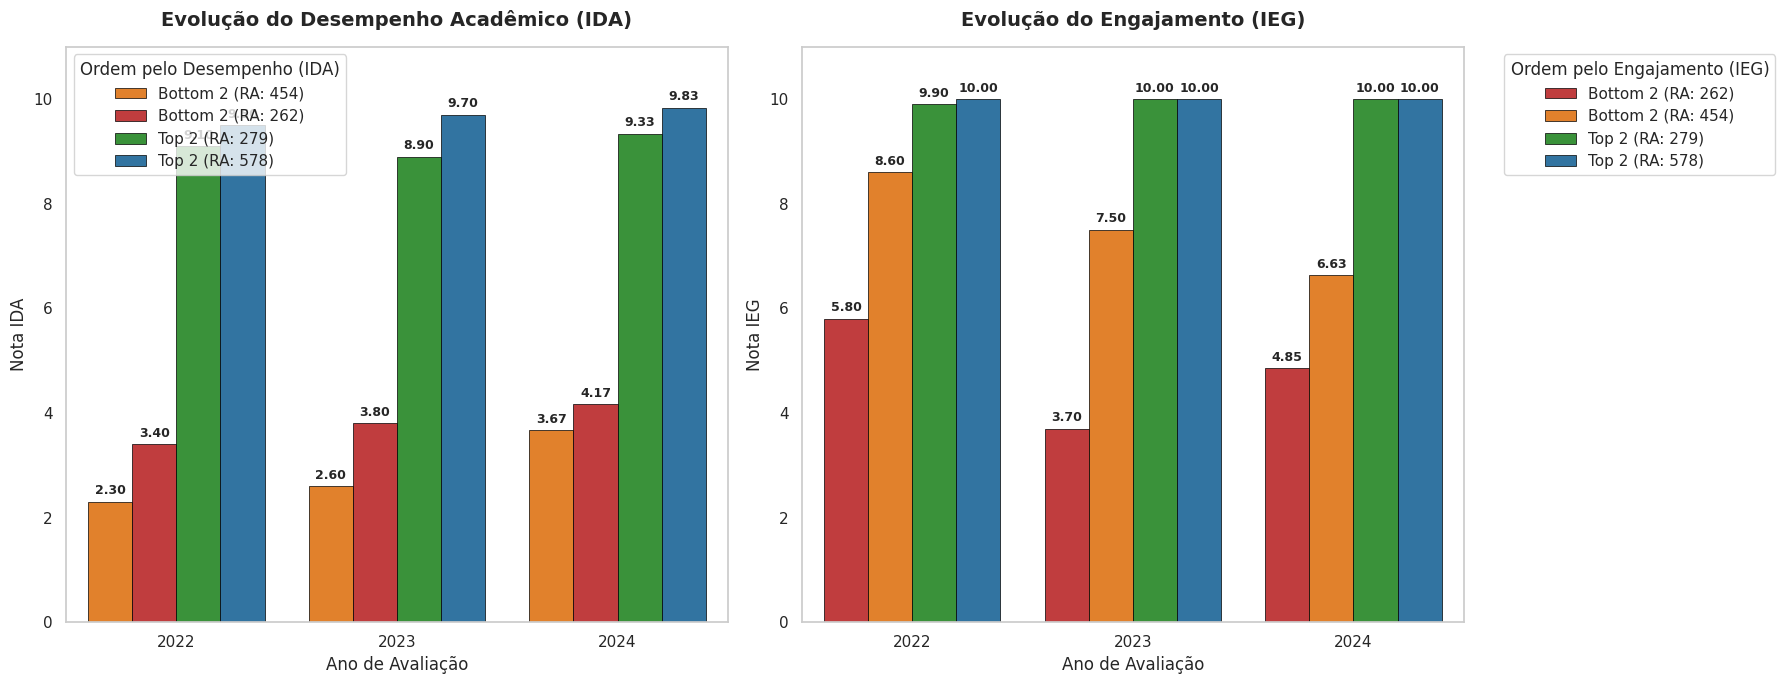

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
print("Carregando a base de dados...")
url_excel = "https://raw.githubusercontent.com/LuciAguiar/DataThon/main/BASE_CONSOLIDADA.xlsx"
df = pd.read_excel(url_excel, sheet_name='Sheet1')

# 2. Limpeza e conversão
df['ANO'] = pd.to_numeric(df['ANO'], errors='coerce')
df = df.dropna(subset=['ANO'])
df = df[df['FASE_ESCOLAR'] != 7]

# 3. Remover alunos com notas acadêmicas ou INDE zerados
df = df[(df['INDE'] > 0) & (df['IDA'] > 0)]

# 4. Filtrar apenas alunos presentes nos 3 anos (2022, 2023, 2024)
anos_por_ra = df.groupby('RA')['ANO'].apply(set)
ra_3_anos = anos_por_ra[anos_por_ra.apply(lambda x: {2022, 2023, 2024}.issubset(x))].index
df_3_anos = df[df['RA'].isin(ra_3_anos)]

# 5. Identificar os 2 menores e 2 maiores INDEs (média dos 3 anos)
inde_avg = df_3_anos.groupby('RA')['INDE'].mean().sort_values()
menores_ra = inde_avg.head(2).index.tolist()
maiores_ra = inde_avg.tail(2).index.tolist()
ras_extremos = menores_ra + maiores_ra

# 6. Preparar os dados para o gráfico
df_plot = df_3_anos[df_3_anos['RA'].isin(ras_extremos)].copy()

def classificar_perfil(ra):
    if ra in menores_ra:
        return f'Bottom 2 (RA: {ra})'
    else:
        return f'Top 2 (RA: {ra})'

df_plot['Perfil'] = df_plot['RA'].apply(classificar_perfil)
df_plot = df_plot.sort_values(by=['ANO'])

# ==========================================
# 7. ORDENAÇÃO DINÂMICA POR INDICADOR
# ==========================================
# Calcula a média de cada perfil no IDA e no IEG para definir a ordem crescente
ordem_ida = df_plot.groupby('Perfil')['IDA'].mean().sort_values().index.tolist()
ordem_ieg = df_plot.groupby('Perfil')['IEG'].mean().sort_values().index.tolist()

# 8. Criar e estilizar a figura
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# Paleta de cores baseada diretamente no RA para manter a cor do aluno igual nos dois gráficos
paleta_cores = {
    f'Bottom 2 (RA: {menores_ra[0]})': '#d62728', # Vermelho
    f'Bottom 2 (RA: {menores_ra[1]})': '#ff7f0e', # Laranja
    f'Top 2 (RA: {maiores_ra[0]})': '#1f77b4',     # Azul
    f'Top 2 (RA: {maiores_ra[1]})': '#2ca02c'     # Verde
}

# --- Gráfico 1: Desempenho Acadêmico (IDA) ---
ax1 = sns.barplot(
    data=df_plot, x='ANO', y='IDA', hue='Perfil',
    palette=paleta_cores, ax=axes[0], edgecolor='black', linewidth=0.5,
    hue_order=ordem_ida # Ordenado pelo valor do IDA
)
axes[0].set_title('Evolução do Desempenho Acadêmico (IDA)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Ano de Avaliação', fontsize=12)
axes[0].set_ylabel('Nota IDA', fontsize=12)
axes[0].set_ylim(0, 11)
ax1.grid(False)

# Ajuste da legenda do Gráfico 1
axes[0].legend(title='Ordem pelo Desempenho (IDA)', loc='upper left')

# Anotações nas barras do IDA
for p in ax1.patches:
    altura = p.get_height()
    if pd.notna(altura) and altura > 0:
        ax1.annotate(format(altura, '.2f'),
                     (p.get_x() + p.get_width() / 2., altura),
                     ha = 'center', va = 'center', xytext = (0, 8),
                     textcoords = 'offset points', fontsize=9, fontweight='bold')

# --- Gráfico 2: Engajamento (IEG) ---
ax2 = sns.barplot(
    data=df_plot, x='ANO', y='IEG', hue='Perfil',
    palette=paleta_cores, ax=axes[1], edgecolor='black', linewidth=0.5,
    hue_order=ordem_ieg # Ordenado pelo valor do IEG
)
axes[1].set_title('Evolução do Engajamento (IEG)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Ano de Avaliação', fontsize=12)
axes[1].set_ylabel('Nota IEG', fontsize=12)
axes[1].set_ylim(0, 11)
ax2.grid(False)

# Ajuste da legenda do Gráfico 2
axes[1].legend(title='Ordem pelo Engajamento (IEG)', bbox_to_anchor=(1.05, 1), loc='upper left')

# Anotações nas barras do IEG
for p in ax2.patches:
    altura = p.get_height()
    if pd.notna(altura) and altura > 0:
        ax2.annotate(format(altura, '.2f'),
                     (p.get_x() + p.get_width() / 2., altura),
                     ha = 'center', va = 'center', xytext = (0, 8),
                     textcoords = 'offset points', fontsize=9, fontweight='bold')

plt.tight_layout()

# 9. Salvar o gráfico como imagem
nome_imagem = 'grafico_influenciadores_extremos_dinamico.jpg'
plt.savefig(nome_imagem, dpi=300, bbox_inches='tight')
plt.show()

### COMPARATIVO DA EVOLUÇÃO DO IDA X IEG AO LONGO DOS ANOS

Carregando a base de dados...


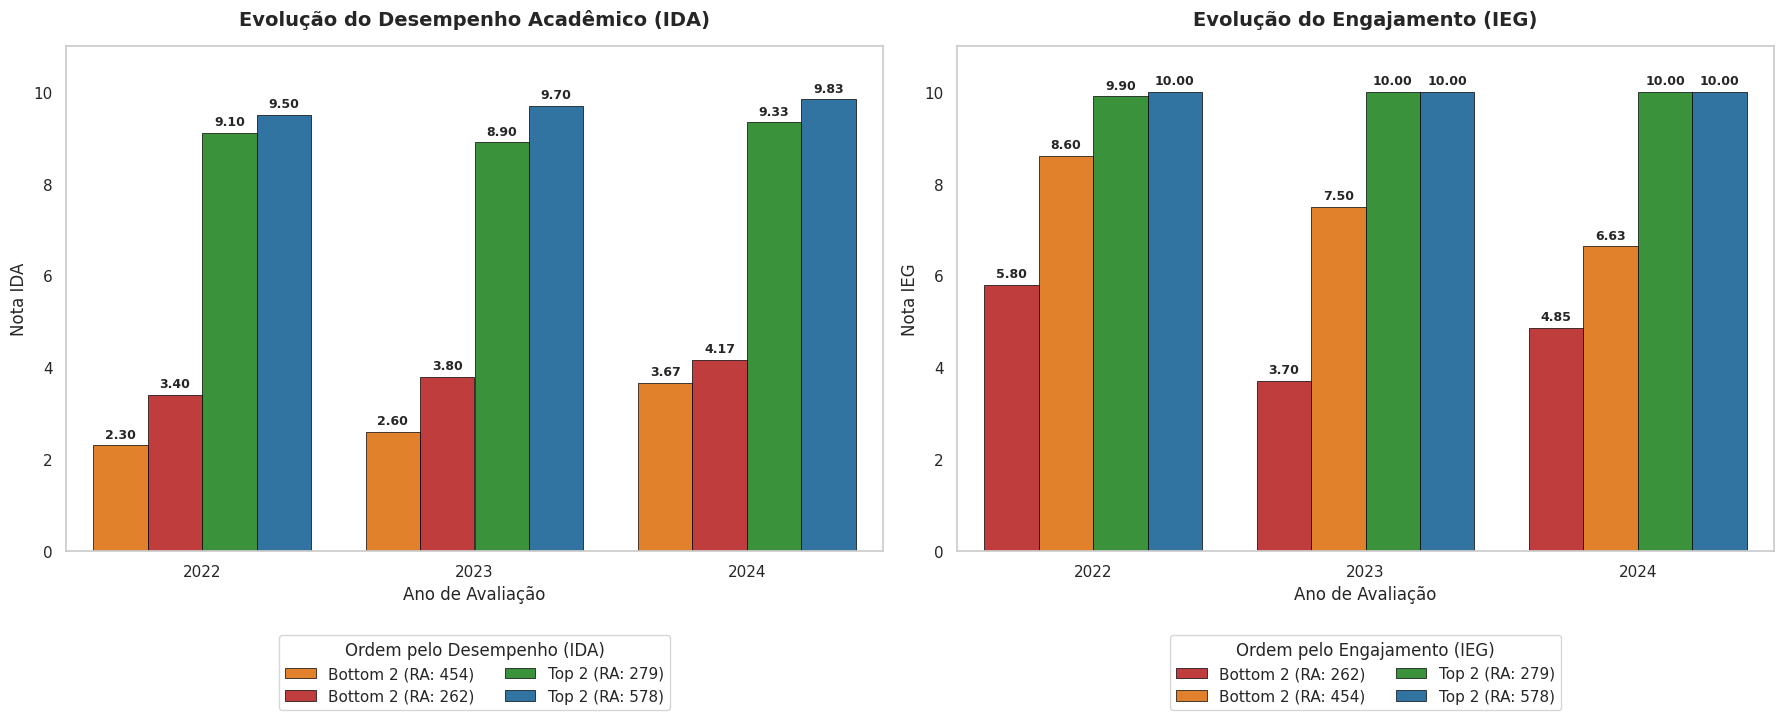

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
print("Carregando a base de dados...")
url_excel = "https://raw.githubusercontent.com/LuciAguiar/DataThon/main/BASE_CONSOLIDADA.xlsx"
df = pd.read_excel(url_excel, sheet_name='Sheet1')

# 2. Limpeza e conversão
df['ANO'] = pd.to_numeric(df['ANO'], errors='coerce')
df = df.dropna(subset=['ANO'])
df = df[df['FASE_ESCOLAR'] != 7]

# 3. Remover alunos com notas acadêmicas ou INDE zerados
df = df[(df['INDE'] > 0) & (df['IDA'] > 0)]

# 4. Filtrar apenas alunos presentes nos 3 anos (2022, 2023, 2024)
anos_por_ra = df.groupby('RA')['ANO'].apply(set)
ra_3_anos = anos_por_ra[anos_por_ra.apply(lambda x: {2022, 2023, 2024}.issubset(x))].index
df_3_anos = df[df['RA'].isin(ra_3_anos)]

# 5. Identificar os 2 menores e 2 maiores INDEs (média dos 3 anos)
inde_avg = df_3_anos.groupby('RA')['INDE'].mean().sort_values()
menores_ra = inde_avg.head(2).index.tolist()
maiores_ra = inde_avg.tail(2).index.tolist()
ras_extremos = menores_ra + maiores_ra

# 6. Preparar os dados para o gráfico
df_plot = df_3_anos[df_3_anos['RA'].isin(ras_extremos)].copy()

def classificar_perfil(ra):
    if ra in menores_ra:
        return f'Bottom 2 (RA: {ra})'
    else:
        return f'Top 2 (RA: {ra})'

df_plot['Perfil'] = df_plot['RA'].apply(classificar_perfil)
df_plot = df_plot.sort_values(by=['ANO'])

# 7. Ordenação dinâmica
ordem_ida = df_plot.groupby('Perfil')['IDA'].mean().sort_values().index.tolist()
ordem_ieg = df_plot.groupby('Perfil')['IEG'].mean().sort_values().index.tolist()

# 8. Criar e estilizar a figura
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

paleta_cores = {
    f'Bottom 2 (RA: {menores_ra[0]})': '#d62728',
    f'Bottom 2 (RA: {menores_ra[1]})': '#ff7f0e',
    f'Top 2 (RA: {maiores_ra[0]})': '#1f77b4',
    f'Top 2 (RA: {maiores_ra[1]})': '#2ca02c'
}

# --- Gráfico 1: Desempenho Acadêmico (IDA) ---
ax1 = sns.barplot(
    data=df_plot, x='ANO', y='IDA', hue='Perfil',
    palette=paleta_cores, ax=axes[0], edgecolor='black', linewidth=0.5,
    hue_order=ordem_ida
)
axes[0].set_title('Evolução do Desempenho Acadêmico (IDA)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Ano de Avaliação', fontsize=12)
axes[0].set_ylabel('Nota IDA', fontsize=12)
axes[0].set_ylim(0, 11)
ax1.grid(False)

# LEGENDA 1: Movida para baixo do gráfico
axes[0].legend(title='Ordem pelo Desempenho (IDA)', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)

for p in ax1.patches:
    altura = p.get_height()
    if pd.notna(altura) and altura > 0:
        ax1.annotate(format(altura, '.2f'),
                     (p.get_x() + p.get_width() / 2., altura),
                     ha = 'center', va = 'center', xytext = (0, 8),
                     textcoords = 'offset points', fontsize=9, fontweight='bold')

# --- Gráfico 2: Engajamento (IEG) ---
ax2 = sns.barplot(
    data=df_plot, x='ANO', y='IEG', hue='Perfil',
    palette=paleta_cores, ax=axes[1], edgecolor='black', linewidth=0.5,
    hue_order=ordem_ieg
)
axes[1].set_title('Evolução do Engajamento (IEG)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Ano de Avaliação', fontsize=12)
axes[1].set_ylabel('Nota IEG', fontsize=12)
axes[1].set_ylim(0, 11)
ax2.grid(False)

# LEGENDA 2: Movida para baixo do gráfico
axes[1].legend(title='Ordem pelo Engajamento (IEG)', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)

for p in ax2.patches:
    altura = p.get_height()
    if pd.notna(altura) and altura > 0:
        ax2.annotate(format(altura, '.2f'),
                     (p.get_x() + p.get_width() / 2., altura),
                     ha = 'center', va = 'center', xytext = (0, 8),
                     textcoords = 'offset points', fontsize=9, fontweight='bold')

# Ajuste fino para dar espaço para as legendas embaixo
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

# 9. Salvar o gráfico como imagem
nome_imagem = 'grafico_influenciadores_extremos_dinamico.jpg'
plt.savefig(nome_imagem, dpi=300, bbox_inches='tight')
plt.show()